# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of four synthetic data generation models:
1. **CTGAN** - Conditional Tabular GAN
2. **CopulaGAN** - GAN-based with copula modeling
3. **Gaussian Copula** - Statistical copula-based approach
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


## Data Loading and Setup


In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
real_estate = fetch_ucirepo(id=477) 
  
# data (as pandas dataframes) 
X = real_estate.data.features 
y = real_estate.data.targets 
  
# metadata 
print(real_estate.metadata) 
  
# variable information 
print(real_estate.variables) 

{'uci_id': 477, 'name': 'Real Estate Valuation', 'repository_url': 'https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set', 'data_url': 'https://archive.ics.uci.edu/static/public/477/data.csv', 'abstract': 'The real estate valuation is a regression problem. The market historical data set of real estate valuation are collected from Sindian Dist., New Taipei City, Taiwan. ', 'area': 'Business', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 414, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Y house price of unit area'], 'index_col': ['No'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C5J30W', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 373, 'type': 'NATIVE', 'title': 'Building real estate valuation models with comparative approach through case-based reasoning', 'authors': 'I. Yeh

In [2]:
import pandas as pd
import numpy as np

X = X.copy()
X = X.drop(columns=["X1 transaction date"], errors="ignore")
if "X4 number of convenience stores" in X.columns:
    X["X4 number of convenience stores"] = pd.to_numeric(
        X["X4 number of convenience stores"], errors="coerce"
    )
data = pd.concat([X, y], axis=1)
target_col = "Y house price of unit area"

# Drop date/time/session/ID features before generator training (high cardinality).
_drop_feature_cols = [
    "Date", "Time", "date_time",
    "session_id", "Session ID", "Session_ID", "session",
    "X1 transaction date",
]
data = data.drop(columns=[c for c in _drop_feature_cols if c in data.columns], errors="ignore")

n_samples = min(1000, len(data))
data = data.sample(n=n_samples, random_state=42).reset_index(drop=True)

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")
    data[col] = data[col].fillna(data[col].median())


# Generating synthetic data

In [3]:
# Import SDV libraries
import sdv
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)


from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer
)
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

# Number of synthetic rows to generate per model
n_samples = len(data)

# Define models in one place
models = {
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata)
}

# Store outputs
synthetic_datasets = {}
diagnostic_reports = {}
quality_reports = {}
summary = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(data)

    synthetic_data = model.sample(n_samples)
    synthetic_datasets[name] = synthetic_data

    diagnostic_report = run_diagnostic(
        real_data=data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )
    quality_report = evaluate_quality(
        real_data= data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )

    diagnostic_reports[name] = diagnostic_report
    quality_reports[name] = quality_report

    diag_score = diagnostic_report.get_score()
    qual_score = quality_report.get_score()
    summary.append((name, diag_score, qual_score))

# Quick comparison table
summary_df = pd.DataFrame(summary, columns=["Model", "Diagnostic Score", "Quality Score"])
summary_df = summary_df.sort_values("Quality Score", ascending=False).reset_index(drop=True)

print("\nModel comparison:")
display(summary_df)

# Example: best model synthetic data
best_model_name = summary_df.loc[0, "Model"]
best_synthetic_data = synthetic_datasets[best_model_name]
print(f"\nBest model by quality score: {best_model_name}")
display(best_synthetic_data.head())

c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sdv\single_table\base.py:183: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sdv\single_table\base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sdv\single_table\base.py:183: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sdv\single_table\base.py:183: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synth


Training CTGAN...


c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Generating report ...

(1/2) Evaluating Data Validity: |██████████| 6/6 [00:00<00:00, 2997.00it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 498.49it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 6/6 [00:00<00:00, 1161.43it/s]|
Column Shapes Score: 80.37%

(2/2) Evaluating Column Pair Trends: |██████████| 15/15 [00:00<00:00, 767.59it/s]|
Column Pair Trends Score: 72.48%

Overall Score (Average): 76.43%


Training CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 6/6 [00:00<00:00, 1901.60it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 463.25it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 6/6 [00:00<00:00, 1174.11it/s]|
Column Shapes Score: 73.55%

(2/2) Evaluating Column Pair Tr

,Model,Diagnostic Score,Quality Score
0,TVAE,1.0,0.921080
1,GaussianCopula,1.0,0.884307
2,CTGAN,1.0,0.764289
3,CopulaGAN,1.0,0.734702



Best model by quality score: TVAE


,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,13.9,402.13771,5,-8.628777,-161.444476,18.0
1,18.2,249.55509,3,-51.646779,146.199357,39.2
2,31.3,456.28944,7,-21.029456,111.028817,53.0
3,16.4,335.81507,8,39.919030,-161.289043,35.5
4,32.3,310.46062,1,74.294129,174.475514,33.6


# 1. Univariate Analysis

### 1.1.  Kolmogorov-Smirnov (K-S) test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 5/5 [00:00<00:00, 1182.89it/s]|
Column Shapes Score: 77.21%

(2/2) Evaluating Column Pair Trends: |██████████| 10/10 [00:00<00:00, 872.78it/s]|
Column Pair Trends Score: 71.85%

Overall Score (Average): 74.53%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 5/5 [00:00<00:00, 1163.34it/s]|
Column Shapes Score: 72.87%

(2/2) Evaluating Column Pair Trends: |██████████| 10/10 [00:00<00:00, 914.09it/s]|
Column Pair Trends Score: 74.83%

Overall Score (Average): 73.85%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 5/5 [00:00<00:00, 964.61it/s]|
Column Shapes Score: 89.45%

(2/2) Evaluating Column Pair Trends: |██████████| 10/10 [00:00<00:00, 876.72it/s]|
Column Pair Trends Score: 97.02%

Overall Score (Average): 93.24%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 5/5 [00:00<00:00, 1248.01it/s]|
Column Shapes Score: 80.43%

(2/2) Evaluating Column Pair Trends

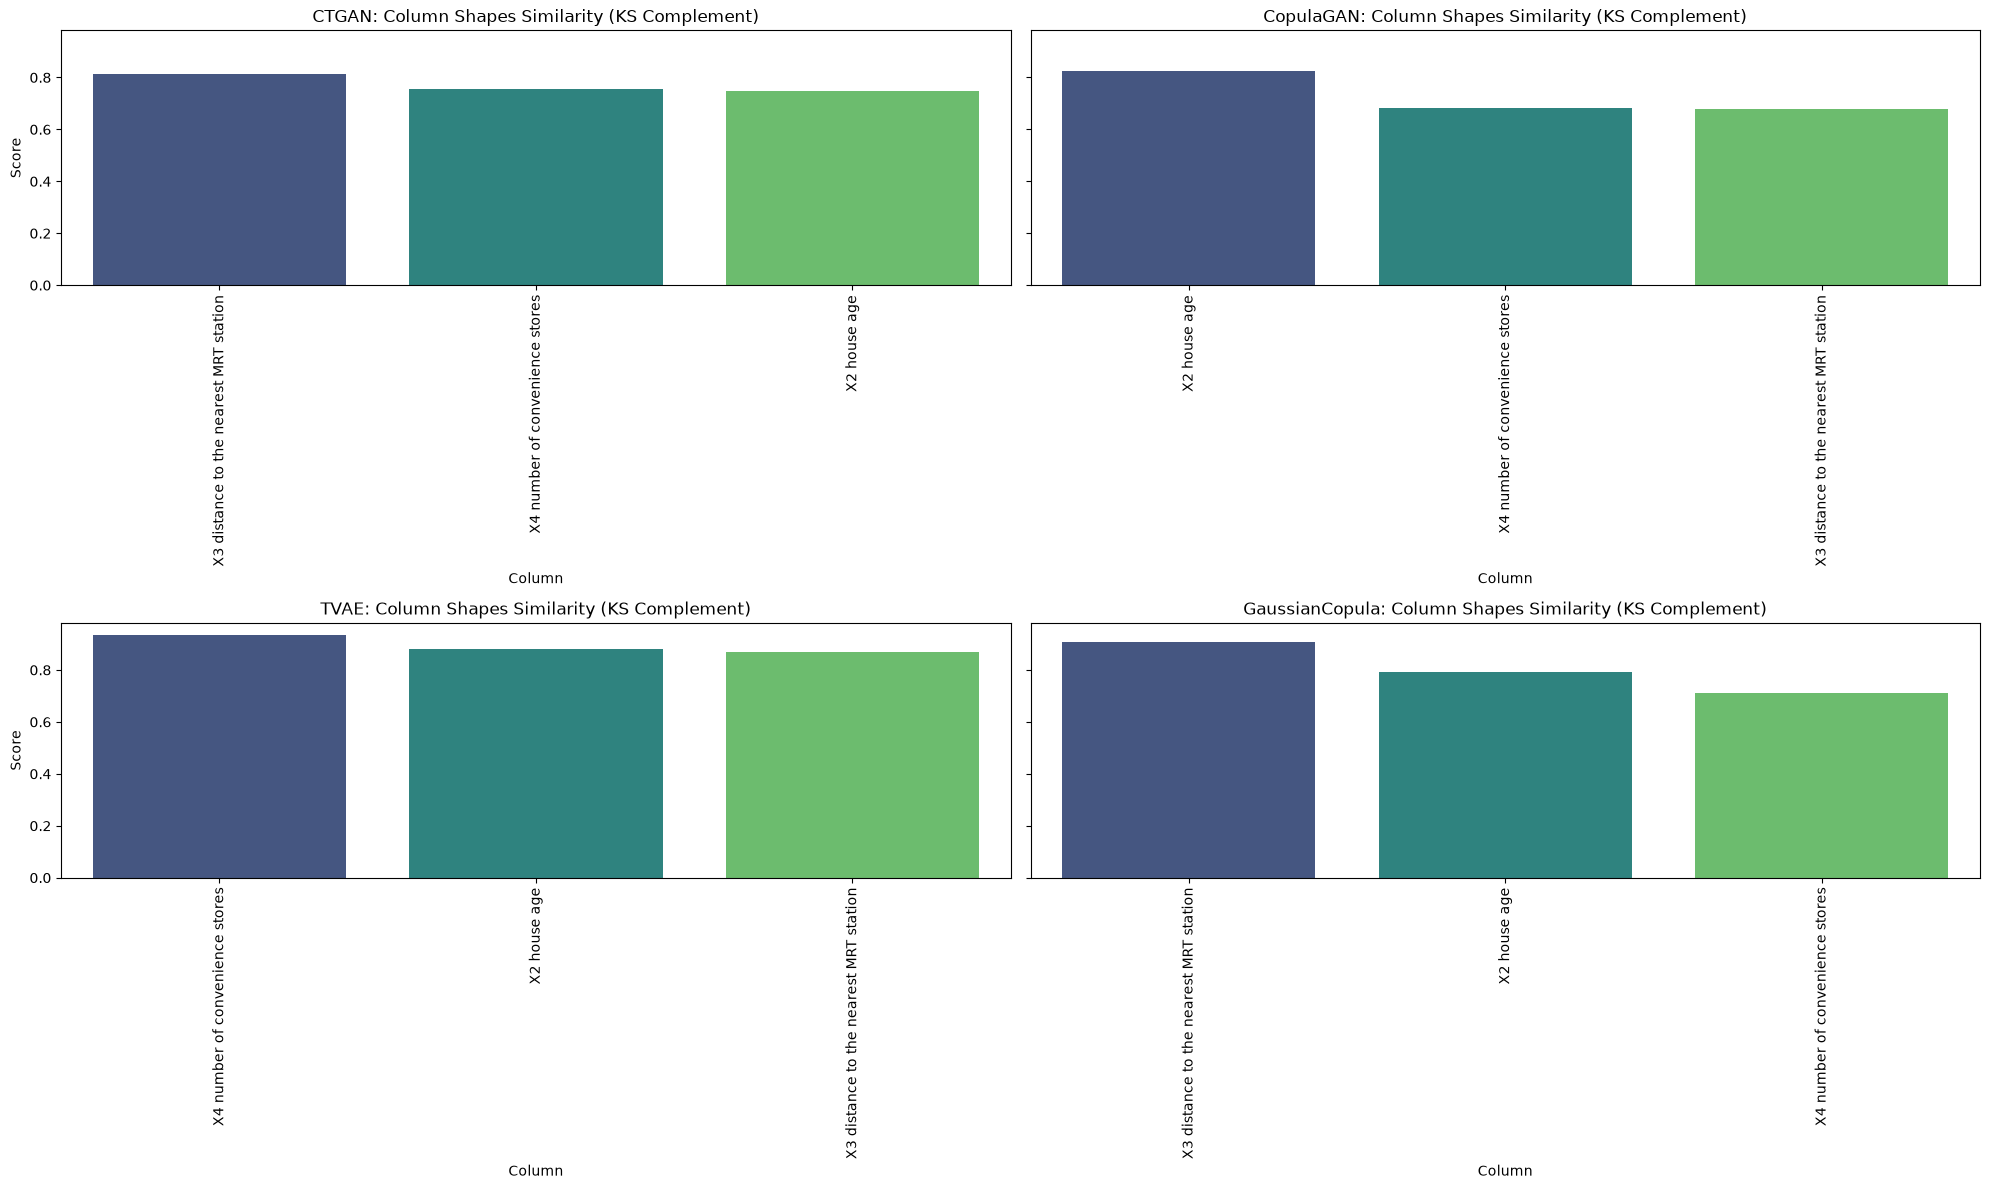

,Column,Metric,Score,Model
0,X3 distance to the nearest MRT station,KSComplement,0.811594,CTGAN
1,X4 number of convenience stores,KSComplement,0.756039,CTGAN
2,X2 house age,KSComplement,0.748792,CTGAN
3,X2 house age,KSComplement,0.823671,CopulaGAN
4,X4 number of convenience stores,KSComplement,0.683575,CopulaGAN
5,X3 distance to the nearest MRT station,KSComplement,0.678744,CopulaGAN
6,X4 number of convenience stores,KSComplement,0.934783,TVAE
7,X2 house age,KSComplement,0.879227,TVAE
8,X3 distance to the nearest MRT station,KSComplement,0.869565,TVAE
9,X3 distance to the nearest MRT station,KSComplement,0.908213,GaussianCopula


In [4]:
import warnings
warnings.filterwarnings("ignore")

from sdv.evaluation.single_table import QualityReport
from sdv.metadata import SingleTableMetadata
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "Y house price of unit area"

real_eval = data.drop(columns=[target_col], errors="ignore").copy()

metadata_eval = SingleTableMetadata()
metadata_eval.detect_from_dataframe(real_eval)

column_shape_details = {}

for model_name in model_order:
    synth_eval = synthetic_datasets[model_name].drop(columns=[target_col], errors="ignore").copy()
    synth_eval = synth_eval[real_eval.columns]

    qr = QualityReport()
    qr.generate(
        real_data=real_eval,
        synthetic_data=synth_eval,
        metadata=metadata_eval.to_dict()
    )
    details = qr.get_details("Column Shapes").sort_values("Score", ascending=False)
    column_shape_details[model_name] = details

fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    sns.barplot(
        x="Column", y="Score",
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Column Shapes Similarity (KS Complement)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)
display(combined_details.head(20))


### 1.2. Jensen–Shannon divergence

In [5]:
import numpy as np
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")


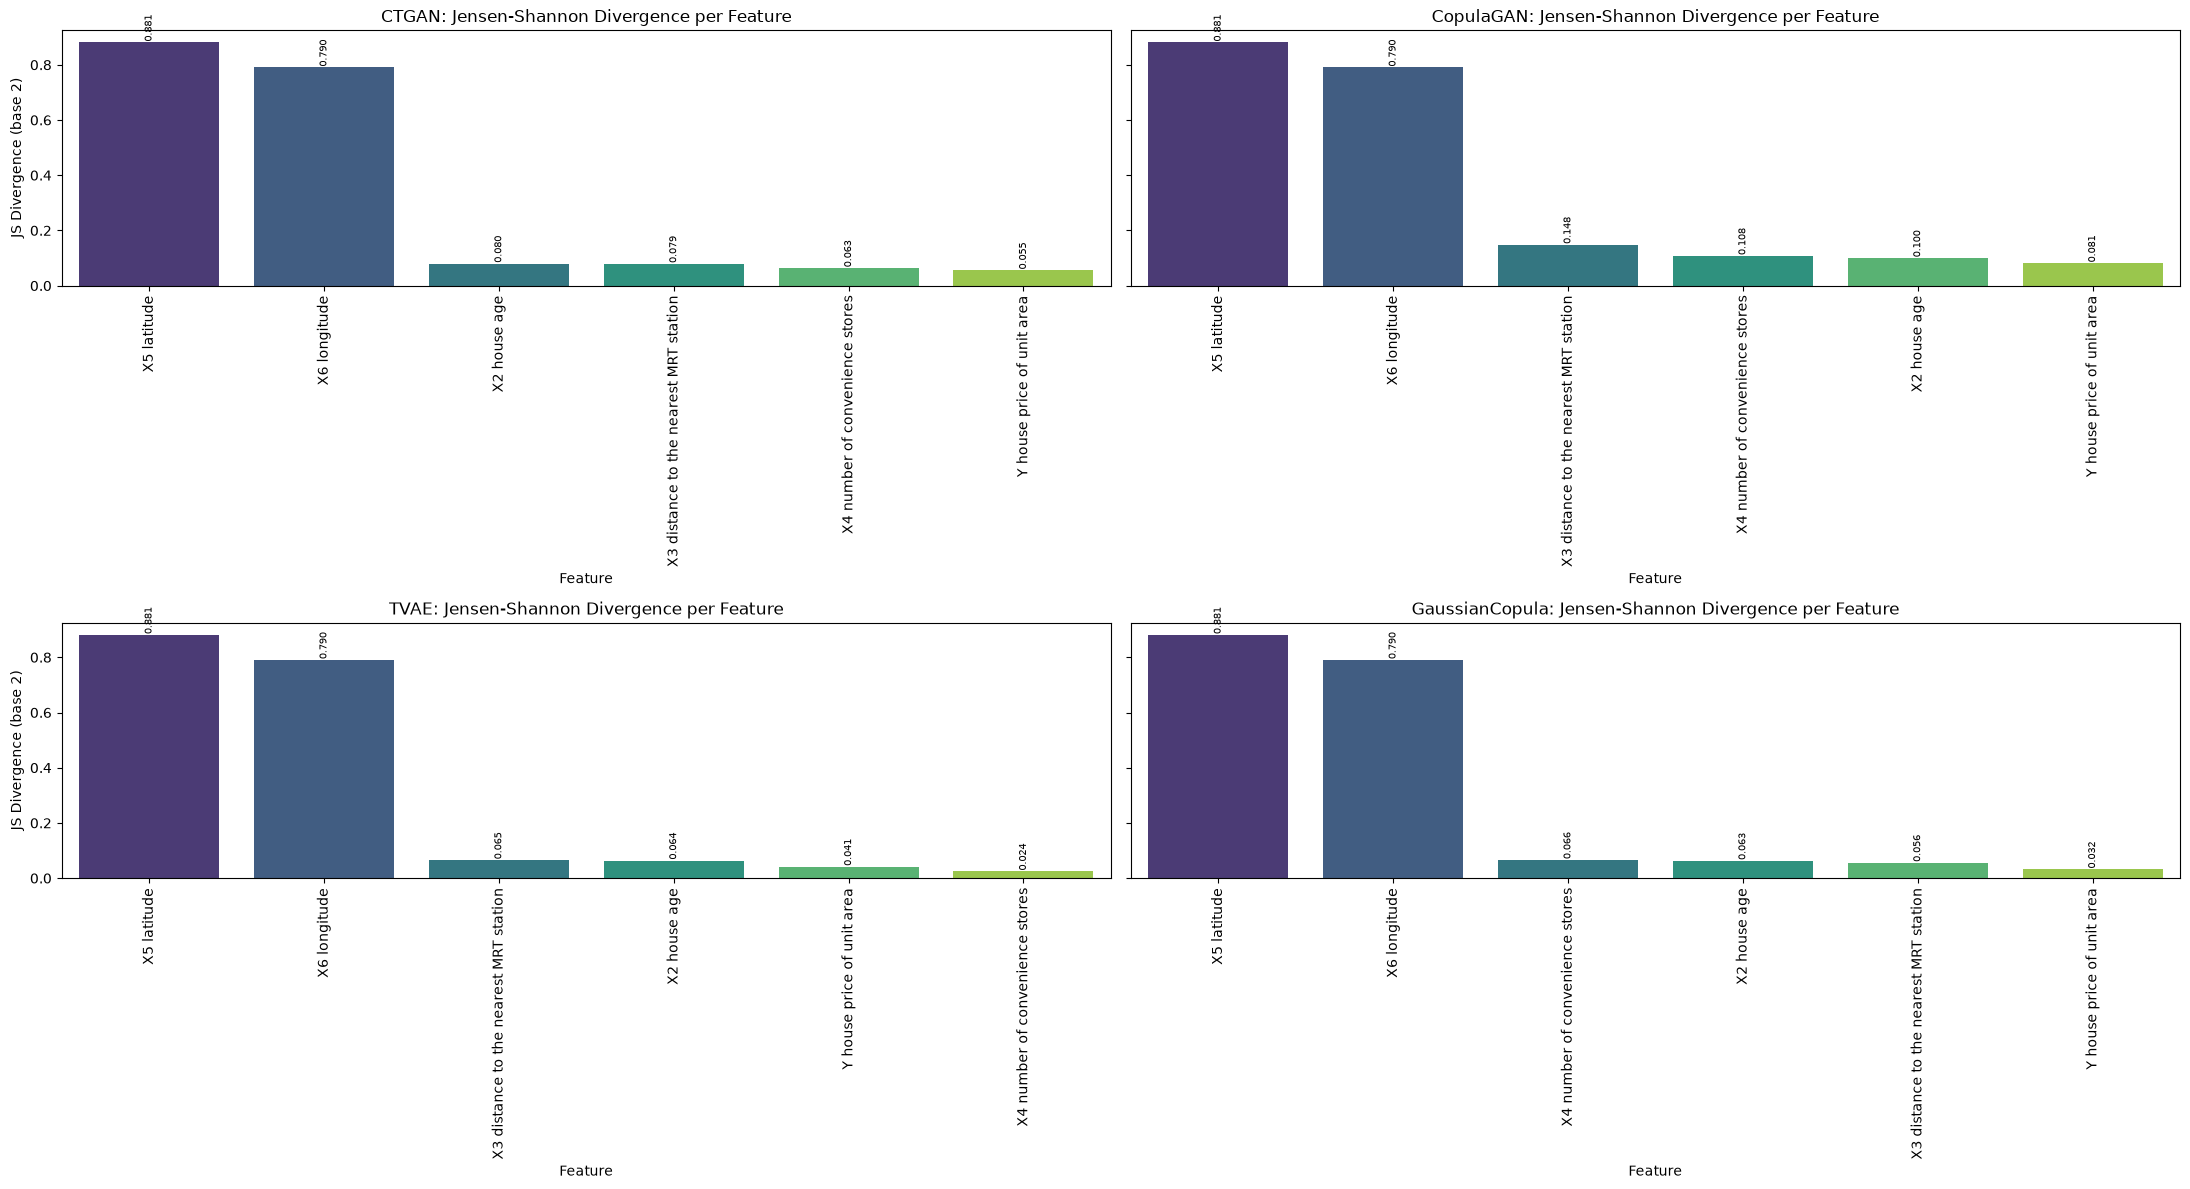

,Feature,JS_Divergence,Model
0,X5 latitude,0.880895,CTGAN
1,X6 longitude,0.790317,CTGAN
2,X2 house age,0.079760,CTGAN
3,X3 distance to the nearest MRT station,0.078988,CTGAN
4,X4 number of convenience stores,0.063342,CTGAN
5,Y house price of unit area,0.055316,CTGAN
6,X5 latitude,0.880895,CopulaGAN
7,X6 longitude,0.790317,CopulaGAN
8,X3 distance to the nearest MRT station,0.147968,CopulaGAN
9,X4 number of convenience stores,0.107659,CopulaGAN


In [6]:
import matplotlib.pyplot as plt, numpy as np
import seaborn as sns
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
js_results_by_model = {}

# Compute JS divergence for each model
for model_name in model_order:
    js_df = compute_js_divergence(
        data,
        synthetic_datasets[model_name],
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)
    js_results_by_model[model_name] = js_df

# Plot all 4 models in one figure (2x2)
fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]
    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df,
        palette="viridis",
        ax=ax
    )

    # Add value labels
    for bar in bars.patches:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.003,
            f"{yval:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    ax.set_title(f"{model_name}: Jensen-Shannon Divergence per Feature")
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence (base 2)")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

# Optional: combined table for quick comparison
all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)
display(all_js.head(20))

### 1.3 Wasserstein Distance



CTGAN - Wasserstein Distance:
X2 house age: 0.1119
X3 distance to the nearest MRT station: 0.0237
X4 number of convenience stores: 0.1275
X5 latitude: 614.0691
X6 longitude: 1430.5623
Y house price of unit area: 0.0316

CopulaGAN - Wasserstein Distance:
X2 house age: 0.0676
X3 distance to the nearest MRT station: 0.1648
X4 number of convenience stores: 0.1522
X5 latitude: 614.0691
X6 longitude: 1430.5623
Y house price of unit area: 0.0631

TVAE - Wasserstein Distance:
X2 house age: 0.0629
X3 distance to the nearest MRT station: 0.0517
X4 number of convenience stores: 0.0367
X5 latitude: 614.0691
X6 longitude: 1430.5623
Y house price of unit area: 0.0321

GaussianCopula - Wasserstein Distance:
X2 house age: 0.0704
X3 distance to the nearest MRT station: 0.0200
X4 number of convenience stores: 0.1512
X5 latitude: 614.0691
X6 longitude: 1430.5623
Y house price of unit area: 0.0133

Model summary (lower is better):


,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein
0,TVAE,340.802477,0.057294,1430.562342
1,GaussianCopula,340.814400,0.110813,1430.562342
2,CTGAN,340.821029,0.119723,1430.562342
3,CopulaGAN,340.846522,0.158499,1430.562342


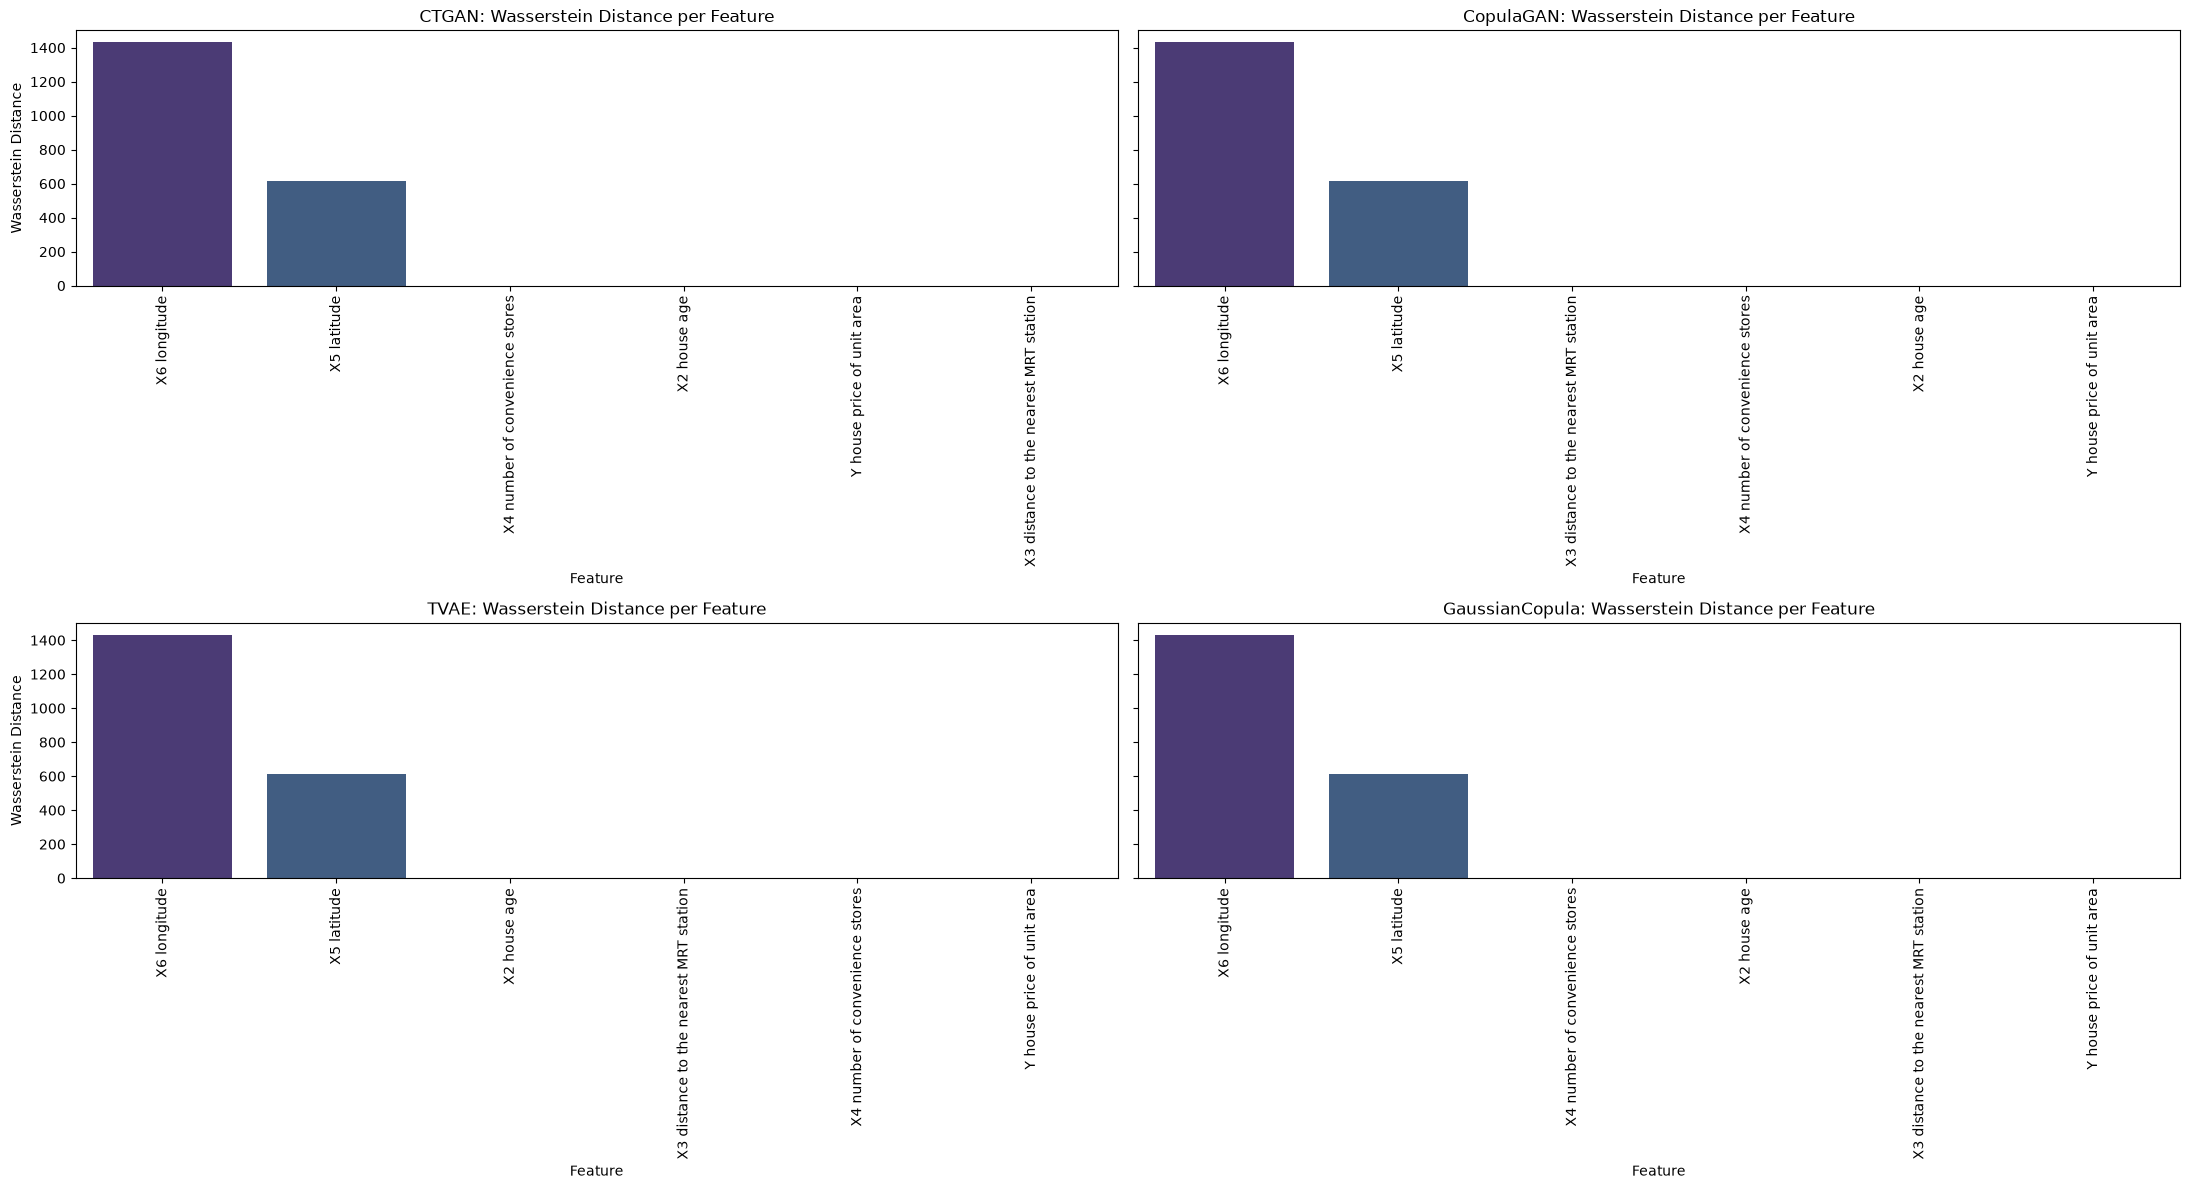

In [7]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assumes these already exist:
# - data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Scale real data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(data),
    columns=data.columns
)

wasserstein_by_model = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]

    # Ensure same column order as real data
    synth_df = synth_df[data.columns]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=synth_df.columns
    )

    dists = []
    print(f"\n{model_name} - Wasserstein Distance:")
    for col in data.columns:
        dist = wasserstein_distance(real_scaled[col], synthetic_scaled[col])
        dists.append((col, dist))
        print(f"{col}: {dist:.4f}")

    dist_df = pd.DataFrame(dists, columns=["Feature", "Wasserstein_Distance"]).sort_values(
        "Wasserstein_Distance", ascending=False
    )
    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": dist_df["Wasserstein_Distance"].mean(),
        "Median_Wasserstein": dist_df["Wasserstein_Distance"].median(),
        "Max_Wasserstein": dist_df["Wasserstein_Distance"].max(),
    })

# Summary table (lower is better)
summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

# Plot all 4 models in one figure
fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name]
    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Wasserstein Distance per Feature")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.tight_layout()
plt.show()

### 1.4 Gower Distance

In [8]:
import numpy as np
import pandas as pd
import gower

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "Y house price of unit area"
id_col = "ID"
drop_cols = [c for c in [id_col, target_col] if c in data.columns]

X_real = data.drop(columns=drop_cols, errors="ignore").copy()

gower_results = []

for model_name in model_order:
    X_synth = synthetic_datasets[model_name].drop(columns=drop_cols, errors="ignore").copy()

    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = X_real[common_cols].reset_index(drop=True).copy()
    Xs = X_synth[common_cols].reset_index(drop=True).copy()

    num_cols = Xr.select_dtypes(include=[np.number]).columns
    Xr[num_cols] = Xr[num_cols].astype(np.float64)
    Xs[num_cols] = Xs[num_cols].astype(np.float64)

    gower_real = 1.0 - gower.gower_matrix(Xr)
    gower_synth = 1.0 - gower.gower_matrix(Xs)

    real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
    synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

    max_intra_real = float(np.max(real_upper))
    avg_intra_real = float(np.mean(real_upper))
    max_intra_synth = float(np.max(synth_upper))
    avg_intra_synth = float(np.mean(synth_upper))

    combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
    gower_combined = 1.0 - gower.gower_matrix(combined)
    n_real = len(Xr)
    cross_block = gower_combined[:n_real, n_real:]

    max_cross = float(np.max(cross_block))
    avg_cross = float(np.mean(cross_block))

    print(f"\n{model_name} - Gower Similarity:")
    print("Intra-set Similarity (Real):")
    print(f"Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}\n")
    print("Intra-set Similarity (Synthetic):")
    print(f"Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}\n")
    print("Cross-set Similarity (Real vs Synthetic):")
    print(f"Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

    gower_results.append({
        "Model": model_name,
        "Max_Intra_Real": max_intra_real,
        "Avg_Intra_Real": avg_intra_real,
        "Max_Intra_Synth": max_intra_synth,
        "Avg_Intra_Synth": avg_intra_synth,
        "Max_Cross_Real_vs_Synth": max_cross,
        "Avg_Cross_Real_vs_Synth": avg_cross,
    })

gower_summary_df = pd.DataFrame(gower_results)
display(gower_summary_df)



CTGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.7682

Intra-set Similarity (Synthetic):
Max = 0.9828, Avg = 0.7193

Cross-set Similarity (Real vs Synthetic):
Max = 0.9747, Avg = 0.7090

CopulaGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.7682

Intra-set Similarity (Synthetic):
Max = 0.9877, Avg = 0.6497

Cross-set Similarity (Real vs Synthetic):
Max = 0.9797, Avg = 0.6676

TVAE - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.7682

Intra-set Similarity (Synthetic):
Max = 0.9849, Avg = 0.7261

Cross-set Similarity (Real vs Synthetic):
Max = 0.9867, Avg = 0.7218

GaussianCopula - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.7682

Intra-set Similarity (Synthetic):
Max = 0.9938, Avg = 0.7035

Cross-set Similarity (Real vs Synthetic):
Max = 0.9840, Avg = 0.7004


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,CTGAN,1.0,0.768227,0.982775,0.719325,0.974742,0.708963
1,CopulaGAN,1.0,0.768227,0.987724,0.649665,0.979723,0.667636
2,TVAE,1.0,0.768227,0.984942,0.726094,0.986683,0.721756
3,GaussianCopula,1.0,0.768227,0.993824,0.703471,0.983962,0.700365


### 1.5 t-SNE Visualization


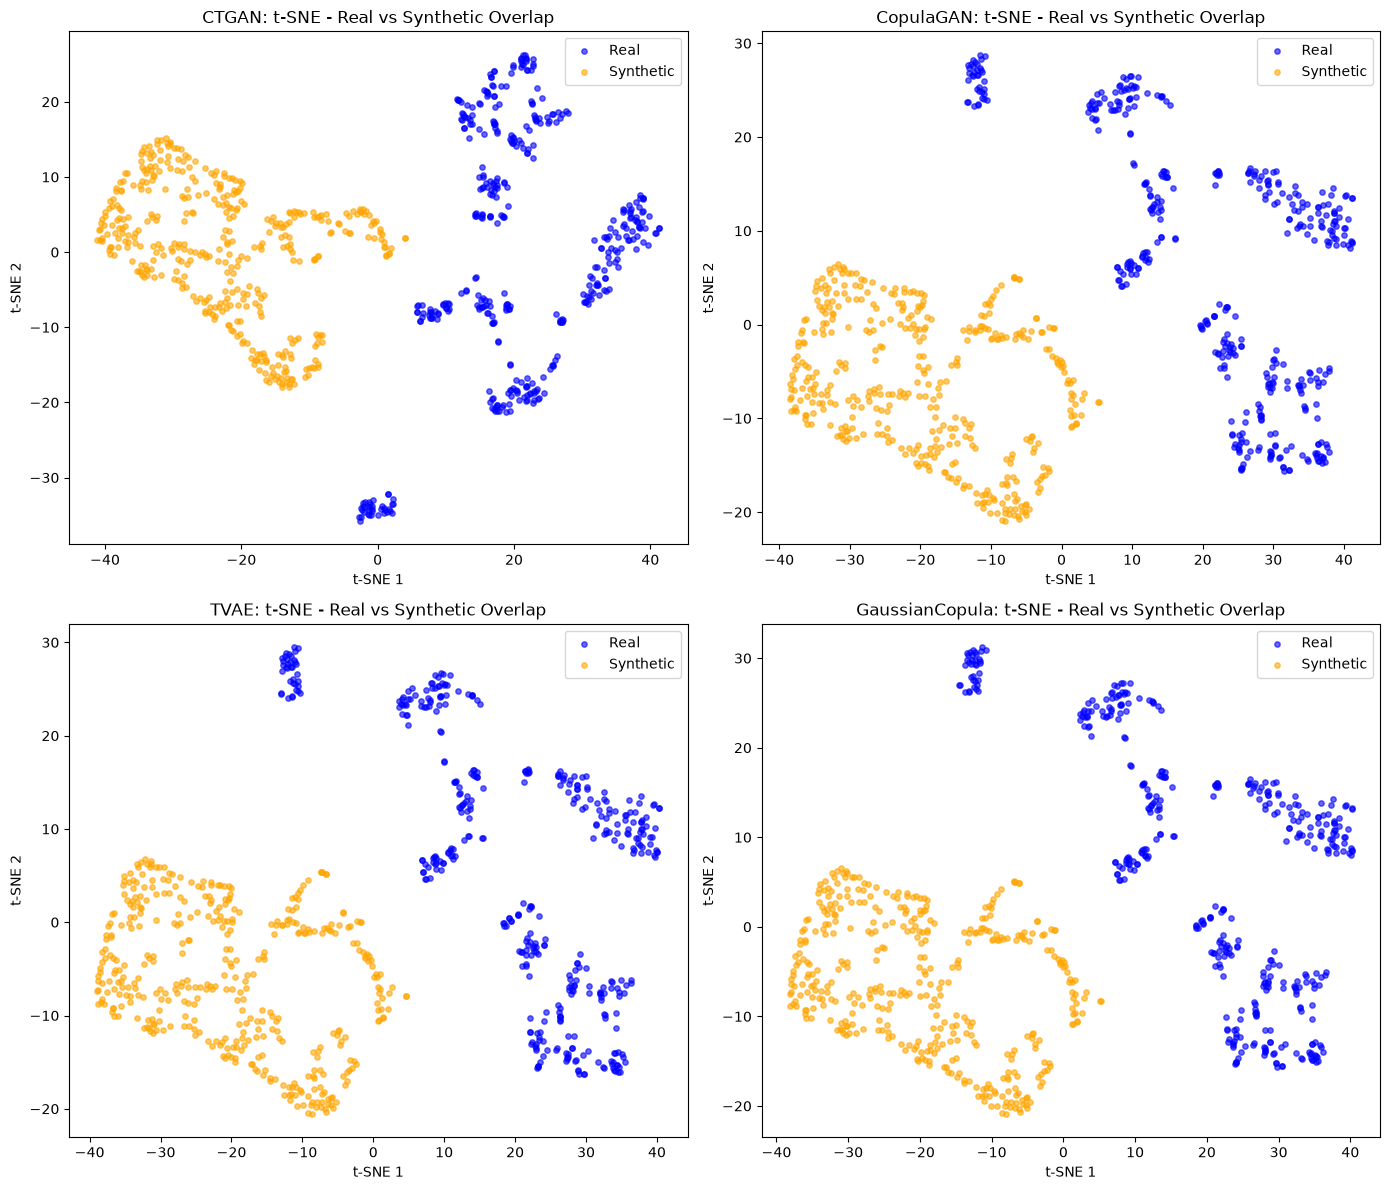

In [9]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumes:
# - data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Scale real data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(data),
    columns=data.columns
)

# Create 2x2 t-SNE plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_datasets[model_name][data.columns]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=synth_df.columns
    )

    combined = np.vstack([real_scaled.values, synthetic_scaled.values])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))

    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=15, label="Real"
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=15, label="Synthetic"
    )

    ax.set_title(f"{model_name}: t-SNE - Real vs Synthetic Overlap")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()

### 1.6 MMD (Maximum Mean Discrepancy)


In [10]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel

def _sample_rows(X, max_rows=2000, seed=42):
    if X.shape[0] <= max_rows:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=max_rows, replace=False)
    return X[idx]

def _median_gamma(X, Y):
    Z = np.vstack([X, Y])
    n = Z.shape[0]
    take = min(1200, n)
    idx = np.random.default_rng(42).choice(n, size=take, replace=False)
    Zs = Z[idx]
    d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
    vals = d2[np.triu_indices_from(d2, k=1)]
    med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
    return 1.0 / (2.0 * med)

def compute_mmd_rbf_safe(X, Y, gamma=None):
    if gamma is None:
        gamma = _median_gamma(X, Y)
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    return float(Kxx.mean() + Kyy.mean() - 2.0 * Kxy.mean())

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "Y house price of unit area"
id_col = None
drop_cols = [c for c in [id_col, target_col] if c is not None and c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
mmd_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].to_numpy(dtype=np.float64)
    X_synth = synth_features[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    Xr = _sample_rows(X_real_scaled, max_rows=2000, seed=42)
    Xs = _sample_rows(X_synth_scaled, max_rows=2000, seed=42)

    mmd_score = compute_mmd_rbf_safe(Xr, Xs, gamma=None)
    mmd_results.append({"Model": model_name, "MMD_Score": mmd_score})

    print(f"{model_name} - MMD score: {mmd_score:.6f}")

mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print("\nMMD comparison (lower is better):")
display(mmd_summary_df)

CTGAN - MMD score: 0.558462
CopulaGAN - MMD score: 0.558462
TVAE - MMD score: 0.558462
GaussianCopula - MMD score: 0.558462

MMD comparison (lower is better):


,Model,MMD_Score
0,CopulaGAN,0.558462
1,GaussianCopula,0.558462
2,CTGAN,0.558462
3,TVAE,0.558462


### 1.7 Cosine Similarity


In [11]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "Y house price of unit area"
id_col = None
drop_cols = [c for c in [id_col, target_col] if c is not None and c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
similarity_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].copy()
    X_synth = synth_features[common_cols].copy()

    if "color" in X_real.columns:
        X_real["color"] = X_real["color"].astype("category").cat.codes
        X_synth["color"] = X_synth["color"].astype("category").cat.codes

    X_real = X_real.apply(pd.to_numeric, errors="coerce").fillna(0).to_numpy(dtype=np.float64)
    X_synth = X_synth.apply(pd.to_numeric, errors="coerce").fillna(0).to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = float(np.mean(cross_sim))
    max_sim = float(np.max(cross_sim))

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)


CTGAN - Sample-Level Similarity:
Average cosine similarity: -0.0507
Maximum cosine similarity: 0.9963

CopulaGAN - Sample-Level Similarity:
Average cosine similarity: -0.0508
Maximum cosine similarity: 0.9962

TVAE - Sample-Level Similarity:
Average cosine similarity: -0.0507
Maximum cosine similarity: 0.9962

GaussianCopula - Sample-Level Similarity:
Average cosine similarity: -0.0507
Maximum cosine similarity: 0.9962

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,TVAE,-0.050741,0.996247
1,GaussianCopula,-0.050746,0.996235
2,CTGAN,-0.050747,0.996253
3,CopulaGAN,-0.050764,0.996248


### 1.8 Nearest Neighbours 


In [12]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "Y house price of unit area"
id_col = None
drop_cols = [c for c in [id_col, target_col] if c is not None and c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].astype(np.float64)
    X_synth = synth_features[common_cols].astype(np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)

    avg_nn_dist = float(np.mean(distances))
    min_nn_dist = float(np.min(distances))
    p5_nn_dist = float(np.percentile(distances, 5))

    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)


CTGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 10329.2578
Minimum NN Distance (Synthetic -> Real): 571.1743
5th Percentile NN Distance: 2148.7283

CopulaGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 10329.2577
Minimum NN Distance (Synthetic -> Real): 571.1637
5th Percentile NN Distance: 2148.7283

TVAE - Privacy Check:
Average NN Distance (Synthetic -> Real): 10329.2579
Minimum NN Distance (Synthetic -> Real): 571.1717
5th Percentile NN Distance: 2148.7310

GaussianCopula - Privacy Check:
Average NN Distance (Synthetic -> Real): 10329.2578
Minimum NN Distance (Synthetic -> Real): 571.1714
5th Percentile NN Distance: 2148.7288

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,TVAE,10329.257934,571.171681,2148.731019
1,GaussianCopula,10329.257821,571.171414,2148.728799
2,CTGAN,10329.257782,571.174334,2148.728338
3,CopulaGAN,10329.257717,571.163680,2148.728251


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,55.159242,31.150442,225321.091310
1,CopulaGAN,71.639749,98.298639,225335.064498
2,TVAE,49.869909,30.284629,225327.474610
3,GaussianCopula,54.663140,36.106195,225317.097874


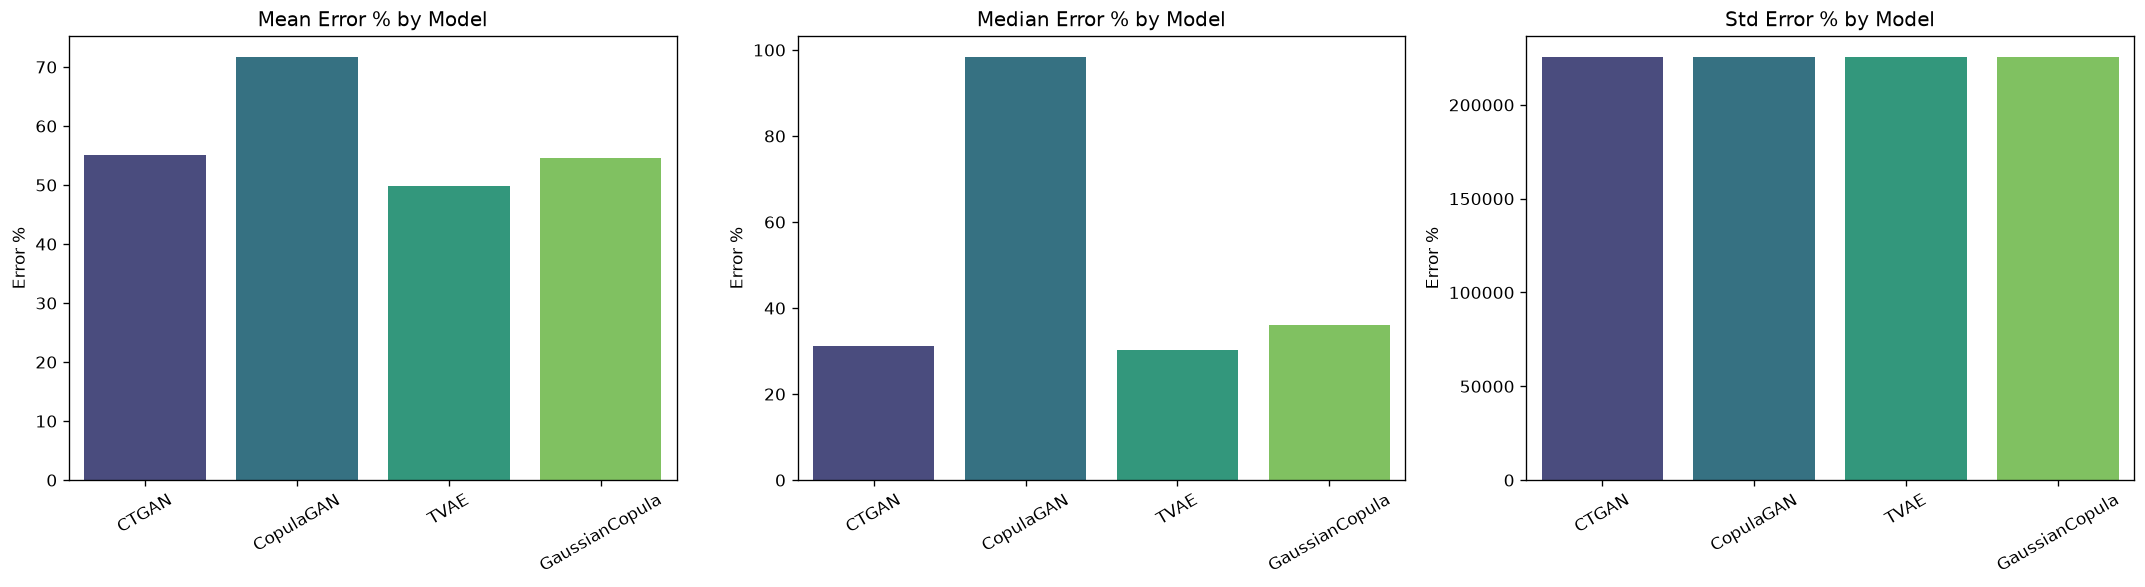

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

drop_from_metrics = []
if "ID" in num_cols:
    drop_from_metrics.append("ID")
if target_col in num_cols:
    drop_from_metrics.append(target_col)

num_cols = [c for c in num_cols if c not in drop_from_metrics]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_means = real_df[num_cols].astype(np.float64).mean()
    synth_means = synth_df[num_cols].astype(np.float64).mean()

    real_stds = real_df[num_cols].astype(np.float64).std(ddof=1)
    synth_stds = synth_df[num_cols].astype(np.float64).std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100.0
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100.0

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True))
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


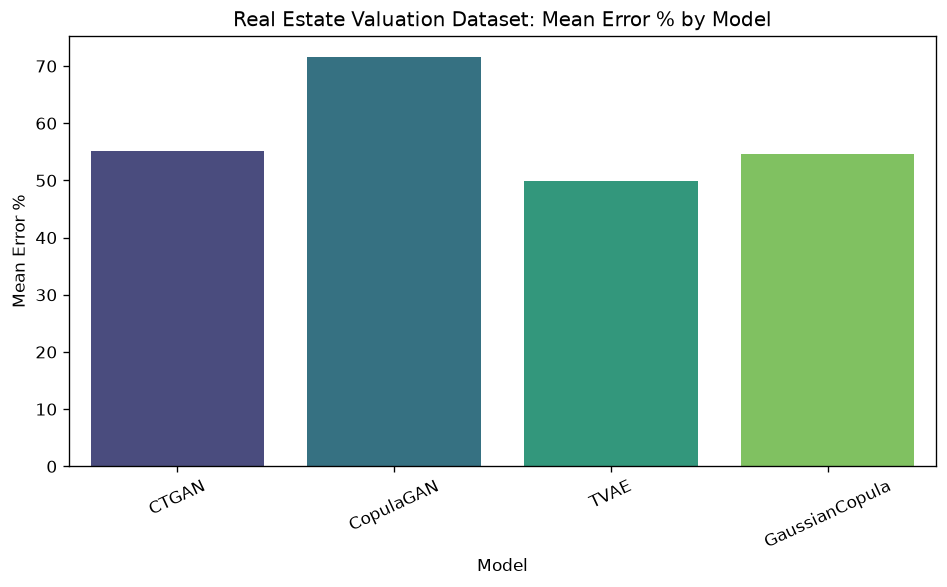

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = summary_df[["Model", "Mean Error %"]].copy()

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=plot_df, x="Model", y="Mean Error %", palette="viridis")
plt.title("Real Estate Valuation Dataset: Mean Error % by Model")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

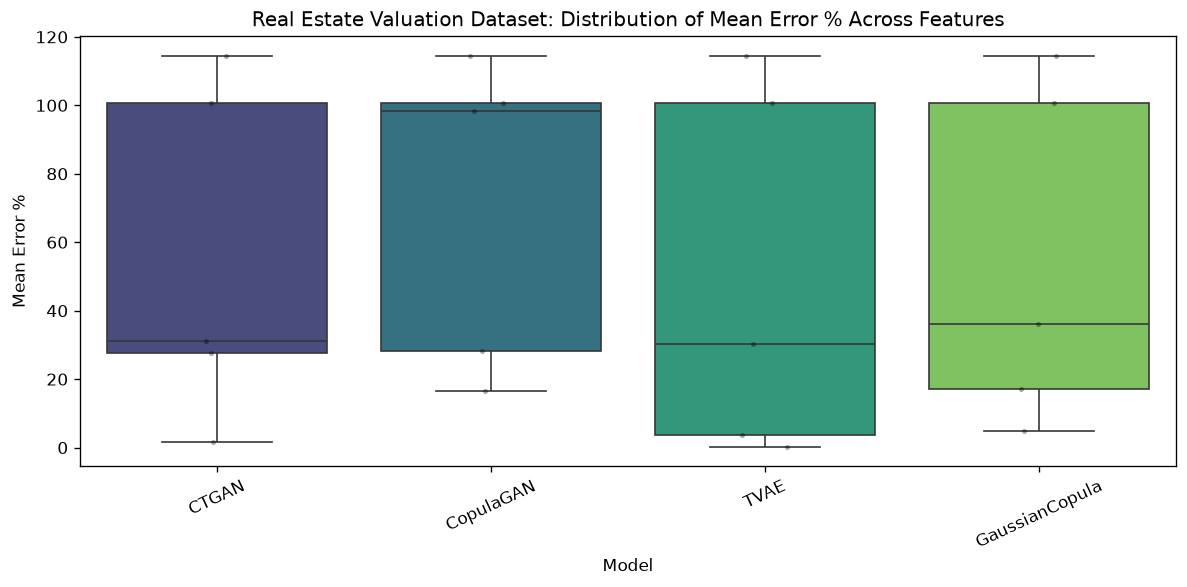

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Real Estate Valuation Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

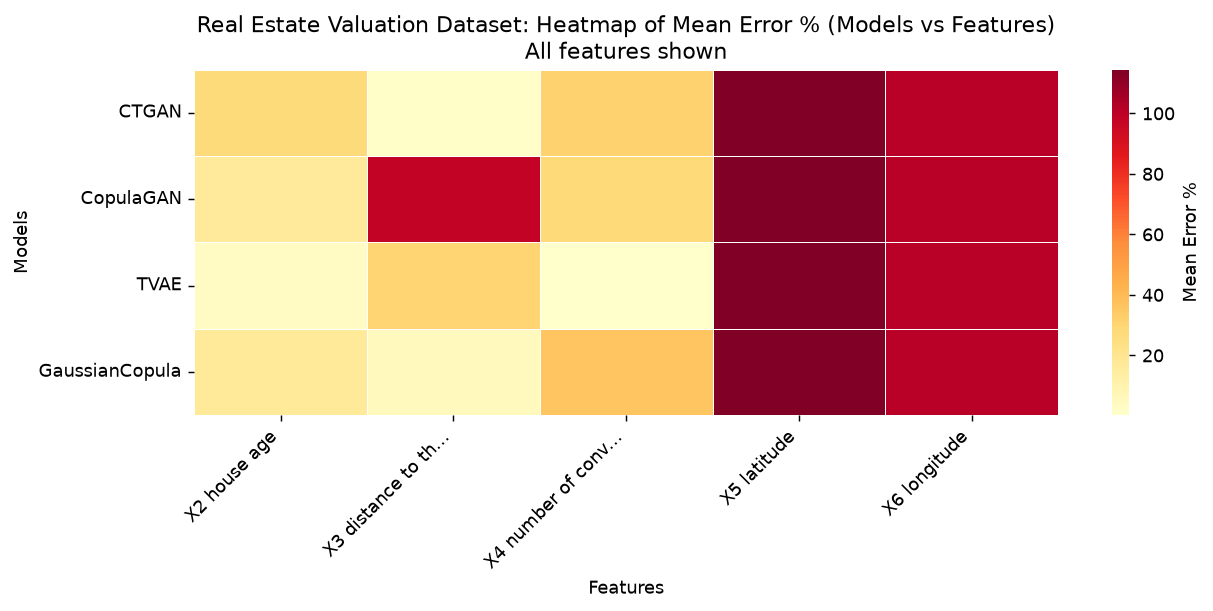

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Real Estate Valuation Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2 Bivariate Analysis


In [17]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def bivariate_quality_regression(real_df, synth_df, target="Y house price of unit area", id_col=None):
    num_cols = real_df.select_dtypes(include=["number"]).columns.tolist()
    num_cols = [c for c in num_cols if c not in [target, id_col] if c is not None]

    scaler = MinMaxScaler()

    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()

    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])

    results_corr = []
    results_target = []

    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            "var_a": a,
            "var_b": b,
            "delta_corr": abs(r_corr - s_corr)
        })

    if target in real_scaled.columns and target in synth_scaled.columns:
        for col in num_cols:
            r_groups = [g[col].values for _, g in real_scaled.groupby(target)]
            s_groups = [g[col].values for _, g in synth_scaled.groupby(target)]

            if len(r_groups) == 2 and len(s_groups) == 2:
                d_real = stats.wasserstein_distance(*r_groups)
                d_synth = stats.wasserstein_distance(*s_groups)
                results_target.append({
                    "feature": col,
                    "delta_wasserstein": abs(d_real - d_synth)
                })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = pd.DataFrame(results_target).sort_values("delta_wasserstein", ascending=False) if results_target else pd.DataFrame(columns=["feature", "delta_wasserstein"])

    return corr_df, target_df


In [18]:
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = data.copy()

target_col = "Y house price of unit area"
id_col = None

if "bivariate_quality_regression" in globals():
    quality_fn = bivariate_quality_regression
else:
    raise NameError("Define `bivariate_quality_regression` before running this cell.")

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_eval = real_df.drop(columns=[id_col], errors="ignore")
    synth_eval = synth_df.drop(columns=[id_col], errors="ignore")

    corr_results, target_results = quality_fn(
        real_df=real_eval,
        synth_df=synth_eval
    )

    all_corr_results[model_name] = corr_results
    all_target_results[model_name] = target_results

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_results.head(10))
    print("=" * 60)
    print(f"{model_name} - Features that differ most by {target_col} class:")
    display(target_results.head(10))
    print("=" * 60)

    corr_metric_col = next((c for c in ["delta_corr", "AbsDiff", "abs_diff", "Difference", "diff"] if c in corr_results.columns), None)
    target_metric_col = next((c for c in ["delta_wasserstein", "AbsDiff", "abs_diff", "Difference", "diff"] if c in target_results.columns), None)

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": corr_results[corr_metric_col].iloc[0] if corr_metric_col and not corr_results.empty else None,
        "MeanTop10CorrDiff": corr_results[corr_metric_col].head(10).mean() if corr_metric_col and not corr_results.empty else None,
        "TopTargetDiff": target_results[target_metric_col].iloc[0] if target_metric_col and not target_results.empty else None,
        "MeanTop10TargetDiff": target_results[target_metric_col].head(10).mean() if target_metric_col and not target_results.empty else None,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)



CTGAN - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
6,X3 distance to the nearest MRT station,X6 longitude,0.842184
4,X3 distance to the nearest MRT station,X4 number of convenience stores,0.562919
5,X3 distance to the nearest MRT station,X5 latitude,0.549848
8,X4 number of convenience stores,X6 longitude,0.461692
7,X4 number of convenience stores,X5 latitude,0.455975
9,X5 latitude,X6 longitude,0.408149
0,X2 house age,X3 distance to the nearest MRT station,0.078739
3,X2 house age,X6 longitude,0.064643
2,X2 house age,X5 latitude,0.045948
1,X2 house age,X4 number of convenience stores,0.040407


CTGAN - Features that differ most by Y house price of unit area class:


,feature,delta_wasserstein



CopulaGAN - Largest differences in pairwise correlations:


...


GaussianCopula - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
6,X3 distance to the nearest MRT station,X6 longitude,0.877297
5,X3 distance to the nearest MRT station,X5 latitude,0.603949
8,X4 number of convenience stores,X6 longitude,0.426162
9,X5 latitude,X6 longitude,0.408149
7,X4 number of convenience stores,X5 latitude,0.391123
4,X3 distance to the nearest MRT station,X4 number of convenience stores,0.210229
0,X2 house age,X3 distance to the nearest MRT station,0.077405
2,X2 house age,X5 latitude,0.057775
3,X2 house age,X6 longitude,0.022952
1,X2 house age,X4 number of convenience stores,0.002141


GaussianCopula - Features that differ most by Y house price of unit area class:


,feature,delta_wasserstein


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,CTGAN,0.842184,0.351050,None,None
1,CopulaGAN,0.864963,0.349182,None,None
2,TVAE,0.758204,0.277793,None,None
3,GaussianCopula,0.877297,0.307718,None,None


### 3 Multivariate Analysis


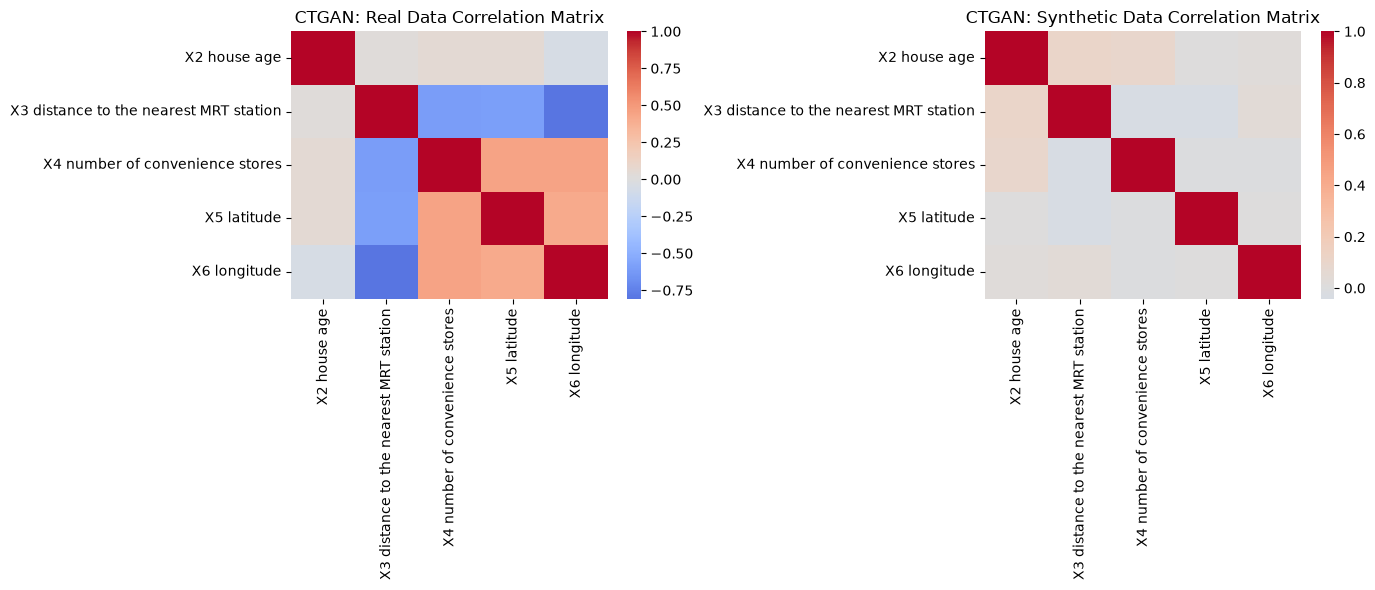

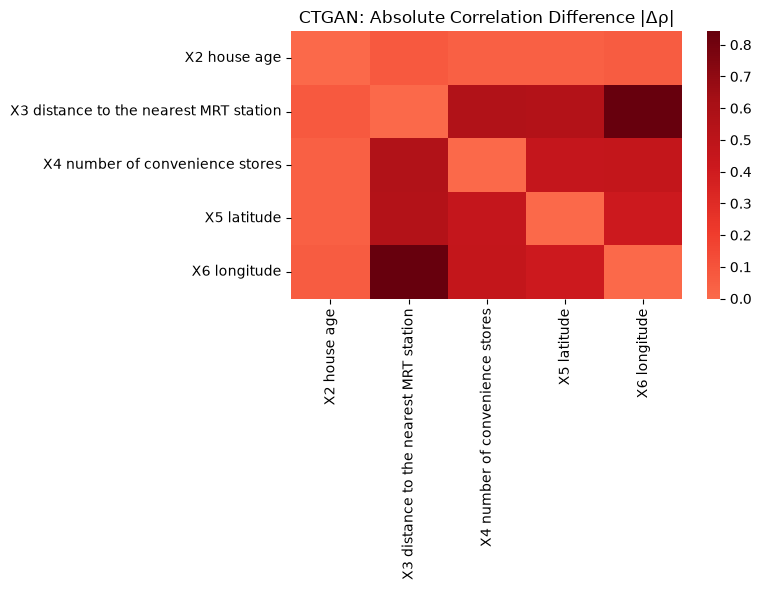

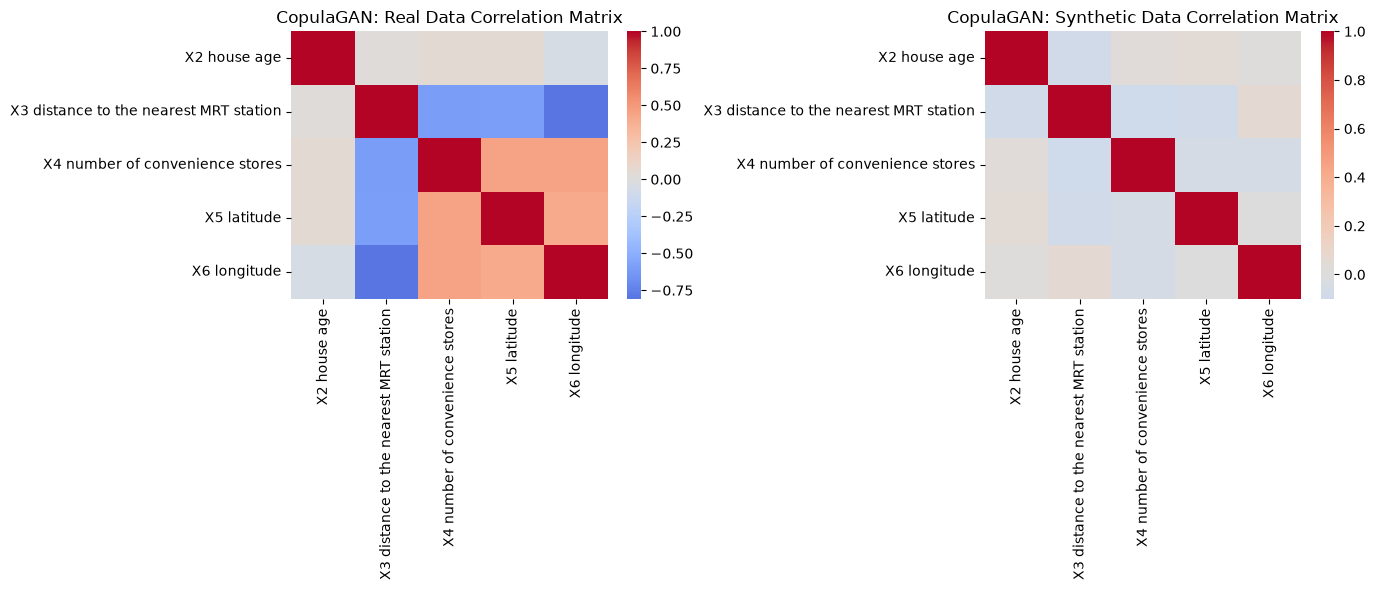

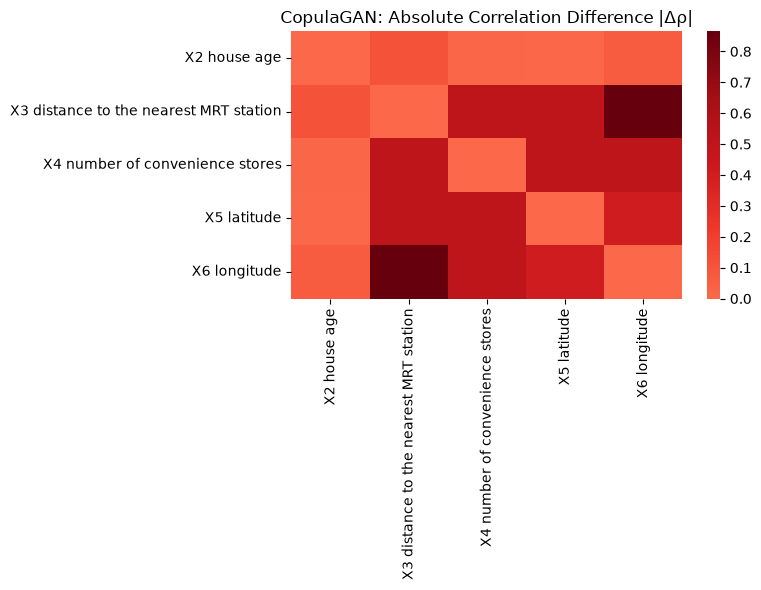

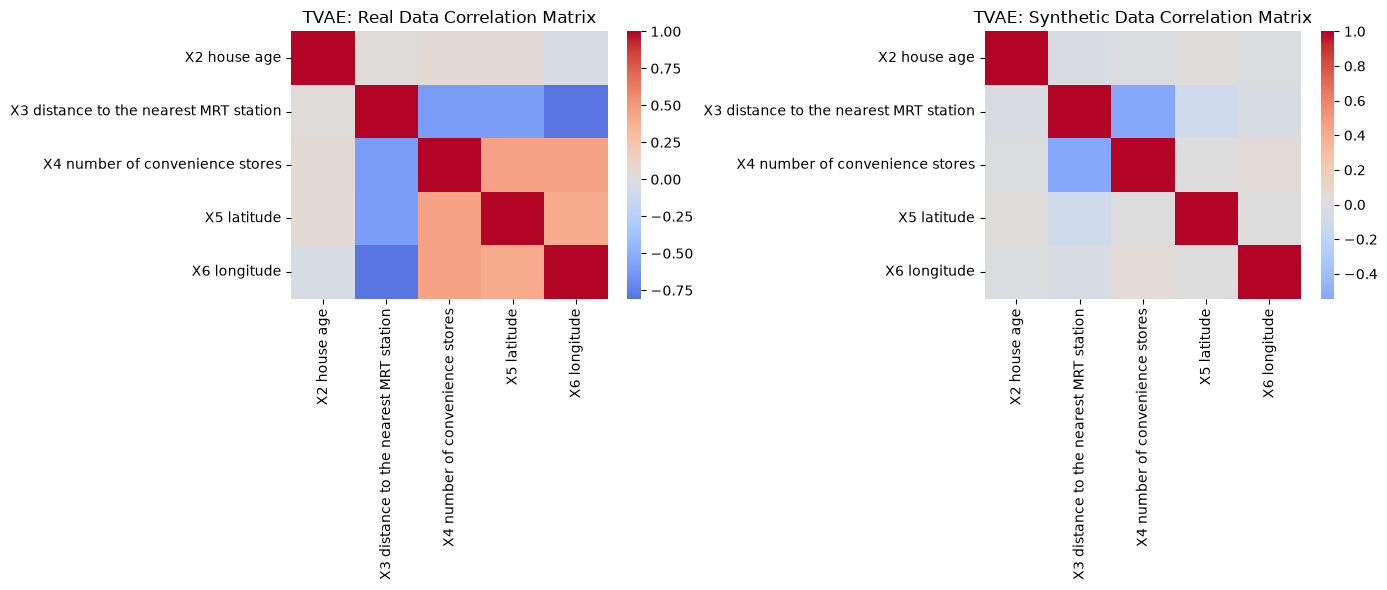

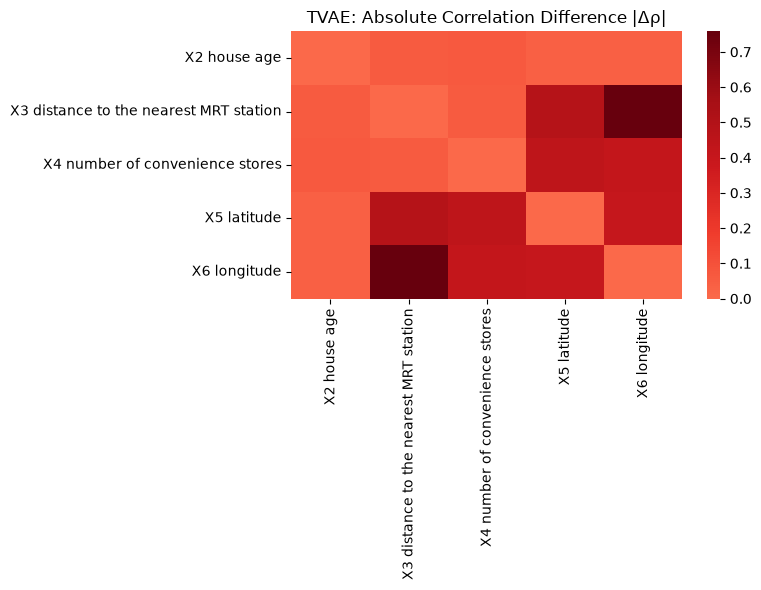

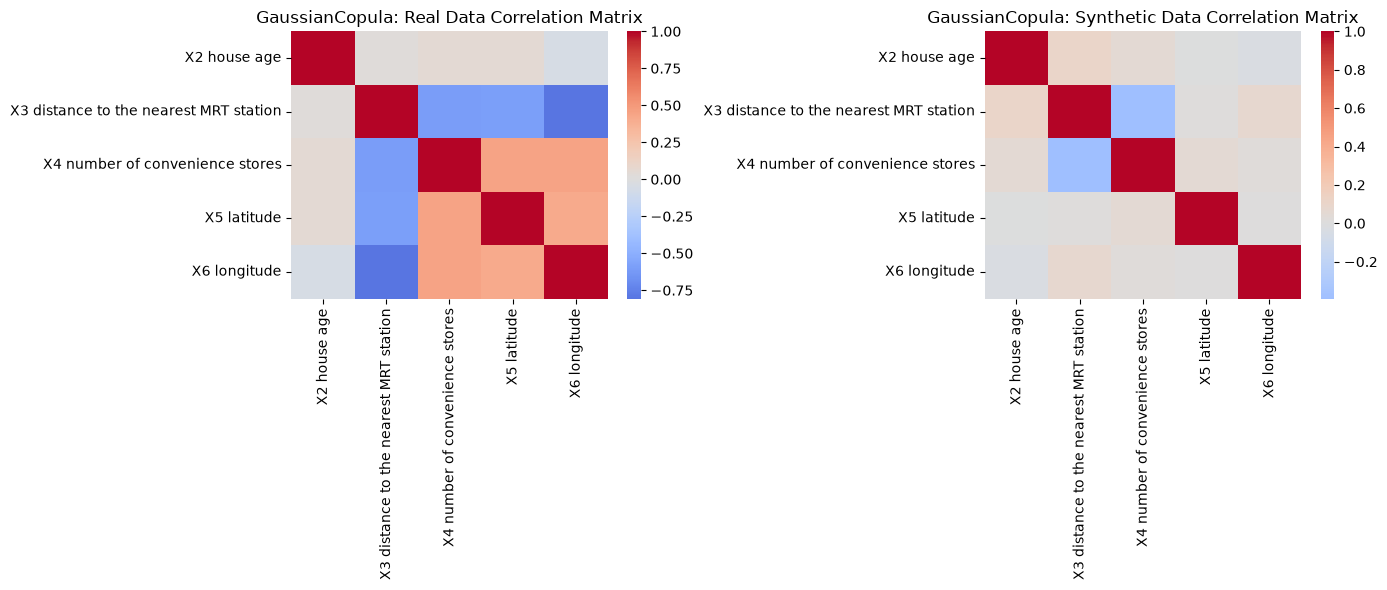

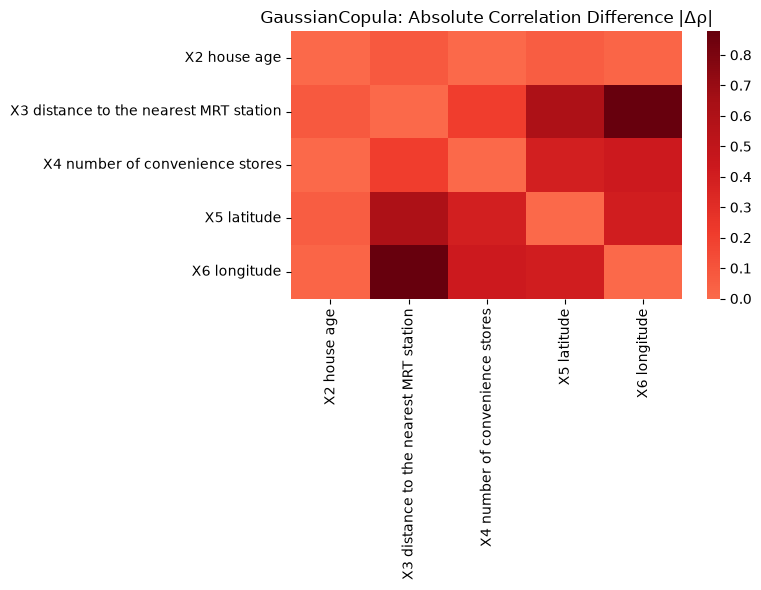

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
target_col = "Y house price of unit area"
id_col = None

num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in [target_col, id_col] if c is not None]

real_corr = real_df[num_cols].corr()

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]
    synth_corr = synth_df[num_cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(real_corr, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(synth_corr, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    diff_corr = (real_corr - synth_corr).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()



CTGAN - Global MMD (RBF): 0.557081


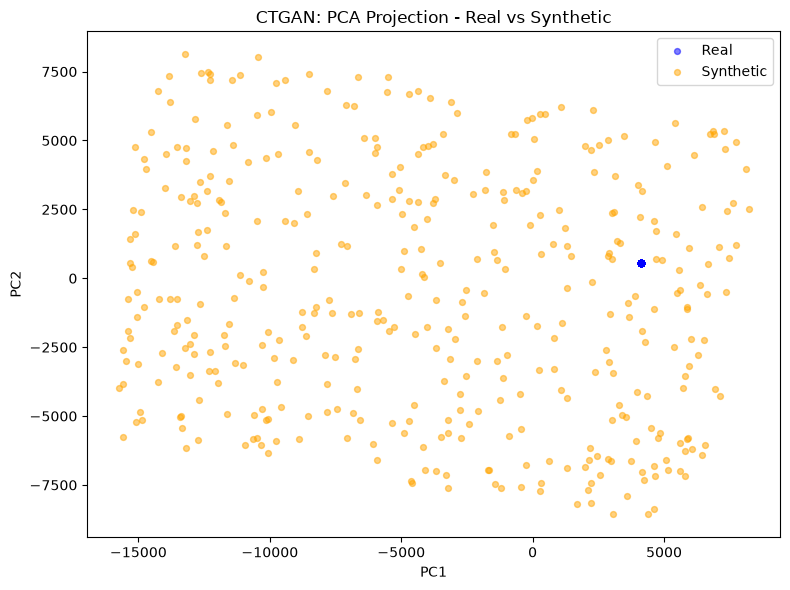

CTGAN - Two-Sample Classifier Accuracy: 0.9836

CopulaGAN - Global MMD (RBF): 0.557081


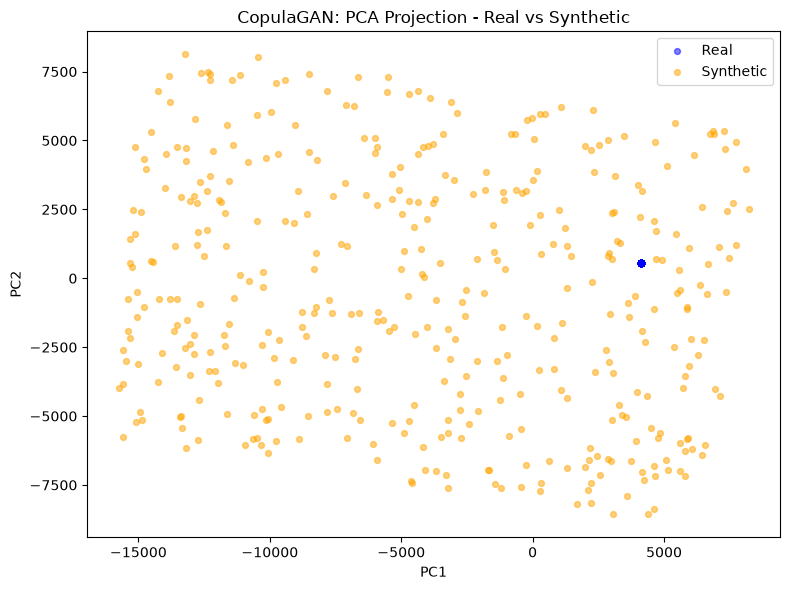

CopulaGAN - Two-Sample Classifier Accuracy: 0.9836

TVAE - Global MMD (RBF): 0.557081


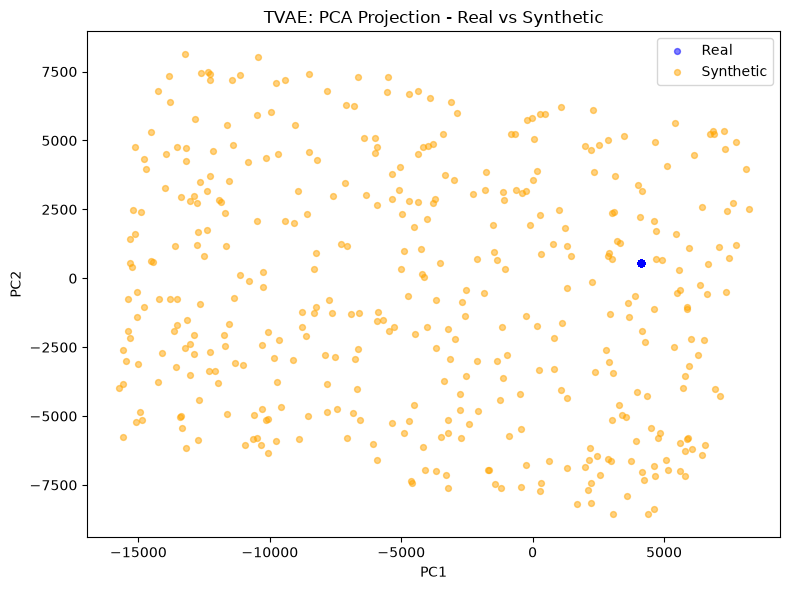

TVAE - Two-Sample Classifier Accuracy: 0.9836

GaussianCopula - Global MMD (RBF): 0.557081


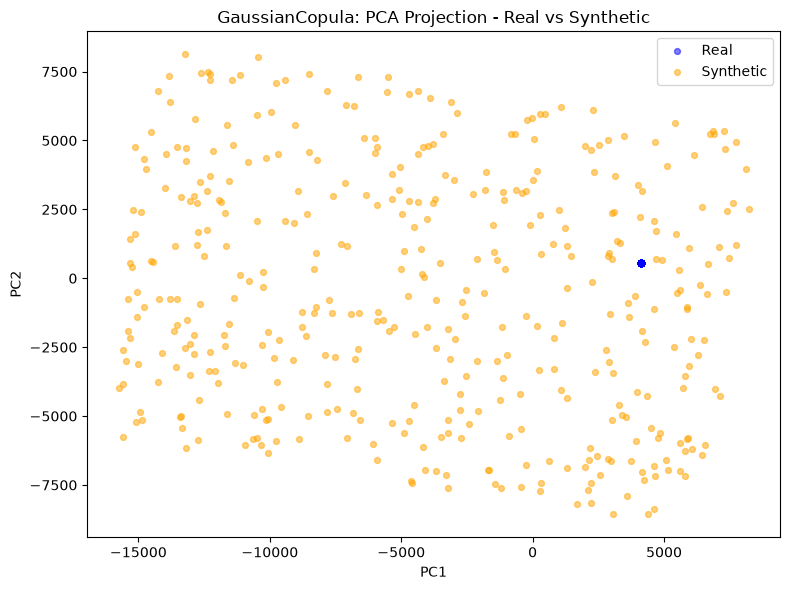

GaussianCopula - Two-Sample Classifier Accuracy: 0.9836

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,CopulaGAN,0.557081,0.983642
1,GaussianCopula,0.557081,0.983642
2,CTGAN,0.557081,0.983642
3,TVAE,0.557081,0.983642


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score


def mmd_rbf(X, Y, gamma=None, gamma_sample_size=1500):
    if gamma is None:
        Z = np.vstack([X, Y])
        n = len(Z)
        k = min(gamma_sample_size, n)
        idx = np.random.default_rng(42).choice(n, size=k, replace=False)
        Zs = Z[idx]
        d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
        vals = d2[np.triu_indices_from(d2, k=1)]
        med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
        gamma = 1.0 / (2.0 * med)

    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)

    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean())


model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "Y house price of unit area"
id_col = None
drop_cols = [c for c in [id_col, target_col] if c is not None and c in data.columns]

X_real_df = data.drop(columns=drop_cols, errors="ignore").copy()
results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    X_synth_df = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = X_real_df.columns.intersection(X_synth_df.columns)
    X_real = X_real_df[common_cols].to_numpy(dtype=np.float64)
    X_synth = X_synth_df[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[labels == "Real", 0], X_pca[labels == "Real", 1],
                color="blue", alpha=0.5, label="Real", s=18)
    plt.scatter(X_pca[labels == "Synthetic", 0], X_pca[labels == "Synthetic", 1],
                color="orange", alpha=0.5, label="Synthetic", s=18)
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))
    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=42
    )

    clf = RandomForestRegressor(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = r2_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": float(mmd_value),
        "C2ST_Accuracy": float(acc)
    })

results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)


# 4 Utility with 10 regressors 


In [21]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'ElasticNet': ElasticNet(random_state=42),
    'SVR-RBF': SVR(kernel='rbf'),
    'KNN': KNeighborsRegressor(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
    'ExtraTrees': ExtraTreesRegressor(random_state=42),
    'GradientBoost': GradientBoostingRegressor(random_state=42),
    'MLP': MLPRegressor(max_iter=2000, random_state=42)
}


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

def evaluate_models(train_df, test_df, label, models, test_size=0.2, seed=42):
    X_train = train_df.drop(columns=[label]).copy()
    y_train = train_df[label].copy()
    X_test = test_df.drop(columns=[label]).copy()
    y_test = test_df[label].copy()
    X_train, _, y_train, _ = train_test_split(X_train, y_train, test_size=test_size, random_state=seed)
    _, X_test, _, y_test = train_test_split(X_test, y_test, test_size=test_size, random_state=seed)
    num_cols = X_train.select_dtypes(include=[np.number]).columns
    X_train = X_train[num_cols].astype(np.float64)
    X_test = X_test[num_cols].astype(np.float64)
    scaler = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)
    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        results.append({"Model": name, "MAE": mean_absolute_error(y_test, preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, preds)), "R2": r2_score(y_test, preds)})
    return pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)


In [23]:
import pandas as pd

label_col = "Y house price of unit area"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(train_df=data, test_df=data, label=label_col, models=models)
print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comparisons = []
for synth_name in model_order:
    _common = [c for c in data.columns if c in synthetic_datasets[synth_name].columns]
    synth_train = synthetic_datasets[synth_name][_common].copy()
    tstr_results = evaluate_models(train_df=synth_train, test_df=data, label=label_col, models=models)
    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)
    comparison = trtr_results.merge(tstr_results, on="Model", suffixes=("_TRTR", "_TSTR"))
    comparison["RMSE_Diff"] = comparison["RMSE_TSTR"] - comparison["RMSE_TRTR"]
    comparison["MAE_Diff"] = comparison["MAE_TSTR"] - comparison["MAE_TRTR"]
    comparison["R2_Drop"] = comparison["R2_TRTR"] - comparison["R2_TSTR"]
    comparison["Synthetic_Model"] = synth_name
    comparison = comparison.sort_values("RMSE_Diff", ascending=False)
    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)
    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)
summary = combined_comparison.groupby("Synthetic_Model", as_index=False)["RMSE_Diff"].mean().sort_values("RMSE_Diff")
print("Average RMSE increase by synthetic generator (lower is better):")
display(summary)


TRTR (Train Real, Test Real)


,Model,MAE,RMSE,R2
0,GradientBoost,5.011186,6.503306,0.759679
1,RandomForest,4.750236,6.542300,0.756788
2,ExtraTrees,4.932865,6.800517,0.737211
3,MLP,5.433684,7.122970,0.711699
4,SVR-RBF,5.693551,7.573021,0.674117
5,KNN,5.873494,7.828184,0.651786
6,Lasso,6.414265,8.398341,0.599216
7,Ridge,6.570079,8.439590,0.595269
8,LinearRegression,6.571629,8.440376,0.595194
9,ElasticNet,6.591839,8.610749,0.578686


CTGAN - TSTR (Train Synthetic, Test Real)


,Model,MAE,RMSE,R2
0,GradientBoost,8.126034,9.860441,0.447520
1,MLP,8.279471,10.376535,0.388173
2,KNN,8.598795,10.486529,0.375134
3,LinearRegression,8.424757,10.646232,0.355956
4,Ridge,8.430386,10.652553,0.355191
5,RandomForest,8.686036,10.660266,0.354257
6,ExtraTrees,8.690229,10.830296,0.333494
7,SVR-RBF,9.291660,11.679804,0.224834
8,ElasticNet,9.638721,11.942218,0.189611
9,Lasso,9.848367,12.167909,0.158691


CTGAN - TRTR vs TSTR Comparison


...

,Model,MAE,RMSE,R2
0,MLP,6.190985,8.097883,0.627380
1,GradientBoost,5.966145,8.104971,0.626727
2,Lasso,6.599519,8.374790,0.601460
3,Ridge,6.821783,8.445590,0.594694
4,LinearRegression,6.828923,8.453304,0.593953
5,ElasticNet,6.678319,8.520672,0.587455
6,RandomForest,6.347614,8.681909,0.571694
7,SVR-RBF,6.922902,8.860621,0.553880
8,KNN,7.078795,9.172489,0.521923
9,ExtraTrees,6.909193,9.410422,0.496799


GaussianCopula - TRTR vs TSTR Comparison


,Model,MAE_TRTR,RMSE_TRTR,R2_TRTR,MAE_TSTR,RMSE_TSTR,R2_TSTR,RMSE_Diff,MAE_Diff,R2_Drop,Synthetic_Model
10,DecisionTree,6.083936,9.249886,0.513821,10.844578,13.757035,-0.075408,4.507149,4.760643,0.589229,GaussianCopula
2,ExtraTrees,4.932865,6.800517,0.737211,6.909193,9.410422,0.496799,2.609905,1.976327,0.240412,GaussianCopula
1,RandomForest,4.750236,6.542300,0.756788,6.347614,8.681909,0.571694,2.139609,1.597378,0.185094,GaussianCopula
0,GradientBoost,5.011186,6.503306,0.759679,5.966145,8.104971,0.626727,1.601666,0.954958,0.132952,GaussianCopula
5,KNN,5.873494,7.828184,0.651786,7.078795,9.172489,0.521923,1.344306,1.205301,0.129864,GaussianCopula
4,SVR-RBF,5.693551,7.573021,0.674117,6.922902,8.860621,0.553880,1.287600,1.229352,0.120237,GaussianCopula
3,MLP,5.433684,7.122970,0.711699,6.190985,8.097883,0.627380,0.974913,0.757301,0.084320,GaussianCopula
8,LinearRegression,6.571629,8.440376,0.595194,6.828923,8.453304,0.593953,0.012928,0.257294,0.001241,GaussianCopula
7,Ridge,6.570079,8.439590,0.595269,6.821783,8.445590,0.594694,0.005999,0.251704,0.000576,GaussianCopula
6,Lasso,6.414265,8.398341,0.599216,6.599519,8.374790,0.601460,-0.023552,0.185254,-0.002245,GaussianCopula


Average RMSE increase by synthetic generator (lower is better):


,Synthetic_Model,RMSE_Diff
3,TVAE,1.206874
2,GaussianCopula,1.306404
0,CTGAN,3.708819
1,CopulaGAN,5.054424


TRTR (Train Real, Test Real)


,Model,MAE,RMSE,R2
0,GradientBoost,5.011186,6.503306,0.759679
1,RandomForest,4.750236,6.542300,0.756788
2,ExtraTrees,4.932865,6.800517,0.737211
3,MLP,5.433684,7.122970,0.711699
4,SVR-RBF,5.693551,7.573021,0.674117
5,KNN,5.873494,7.828184,0.651786
6,Lasso,6.414265,8.398341,0.599216
7,Ridge,6.570079,8.439590,0.595269
8,LinearRegression,6.571629,8.440376,0.595194
9,ElasticNet,6.591839,8.610749,0.578686


CTGAN - TSTR


,Model,MAE,RMSE,R2
0,GradientBoost,8.126034,9.860441,0.447520
1,MLP,8.279471,10.376535,0.388173
2,KNN,8.598795,10.486529,0.375134
3,LinearRegression,8.424757,10.646232,0.355956
4,Ridge,8.430386,10.652553,0.355191
5,RandomForest,8.686036,10.660266,0.354257
6,ExtraTrees,8.690229,10.830296,0.333494
7,SVR-RBF,9.291660,11.679804,0.224834
8,ElasticNet,9.638721,11.942218,0.189611
9,Lasso,9.848367,12.167909,0.158691


CTGAN - TRTR vs TSTR Comparison


,Model,MAE_TRTR,RMSE_TRTR,R2_TRTR,MAE_TSTR,RMSE_TSTR,R2_TSTR,RMSE_Diff,Synthetic_Model
0,GradientBoost,5.011186,6.503306,0.759679,8.126034,9.860441,0.447520,3.357135,CTGAN
1,RandomForest,4.750236,6.542300,0.756788,8.686036,10.660266,0.354257,4.117965,CTGAN
2,ExtraTrees,4.932865,6.800517,0.737211,8.690229,10.830296,0.333494,4.029779,CTGAN
3,MLP,5.433684,7.122970,0.711699,8.279471,10.376535,0.388173,3.253565,CTGAN
4,SVR-RBF,5.693551,7.573021,0.674117,9.291660,11.679804,0.224834,4.106784,CTGAN
5,KNN,5.873494,7.828184,0.651786,8.598795,10.486529,0.375134,2.658345,CTGAN
6,Lasso,6.414265,8.398341,0.599216,9.848367,12.167909,0.158691,3.769567,CTGAN
7,Ridge,6.570079,8.439590,0.595269,8.430386,10.652553,0.355191,2.212963,CTGAN
8,LinearRegression,6.571629,8.440376,0.595194,8.424757,10.646232,0.355956,2.205855,CTGAN
9,ElasticNet,6.591839,8.610749,0.578686,9.638721,11.942218,0.189611,3.331469,CTGAN


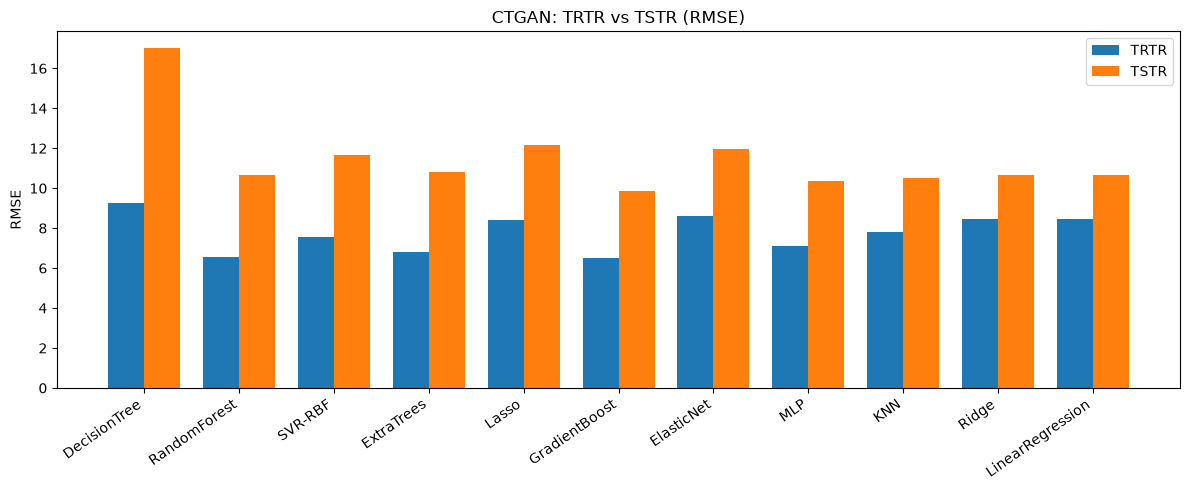

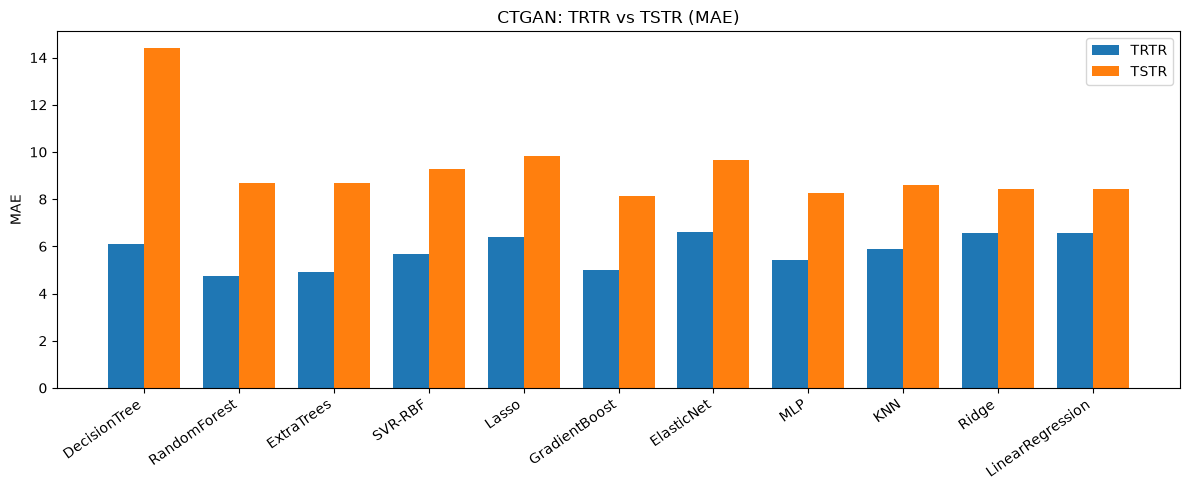

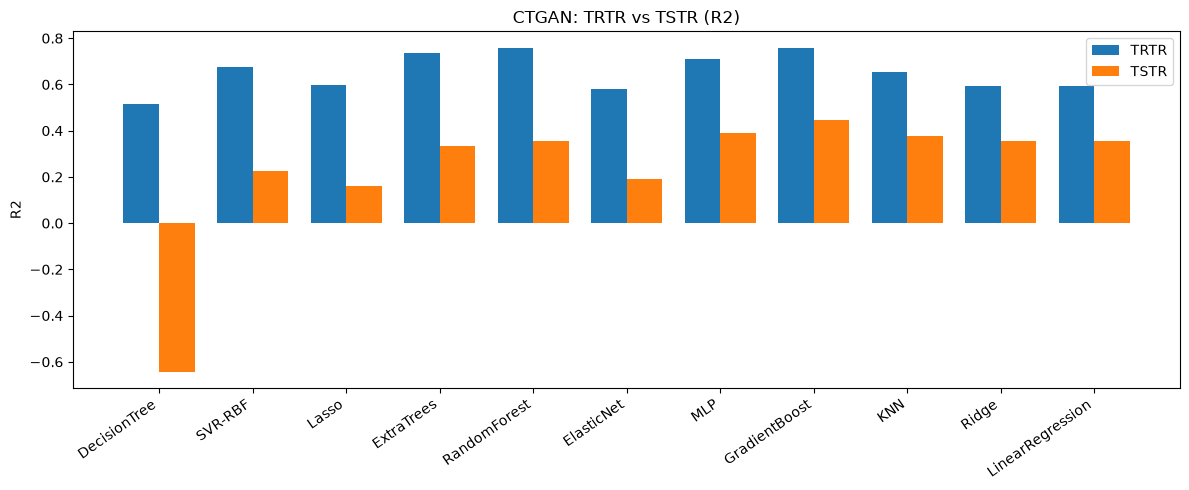

CopulaGAN - TSTR


,Model,MAE,RMSE,R2
0,MLP,7.539247,9.705451,0.464752
1,GradientBoost,8.623242,11.078545,0.302589
2,RandomForest,9.329892,11.567291,0.239697
3,ExtraTrees,10.283133,12.432572,0.121695
4,KNN,9.391807,12.490817,0.113446
5,LinearRegression,10.383203,12.796779,0.069482
6,Ridge,10.386981,12.801357,0.068816
7,Lasso,11.011749,13.616011,-0.053473
8,ElasticNet,11.050257,13.618237,-0.053817
9,SVR-RBF,11.181812,14.044213,-0.120775


CopulaGAN - TRTR vs TSTR Comparison


,Model,MAE_TRTR,RMSE_TRTR,R2_TRTR,MAE_TSTR,RMSE_TSTR,R2_TSTR,RMSE_Diff,Synthetic_Model
0,GradientBoost,5.011186,6.503306,0.759679,8.623242,11.078545,0.302589,4.575239,CopulaGAN
1,RandomForest,4.750236,6.542300,0.756788,9.329892,11.567291,0.239697,5.024991,CopulaGAN
2,ExtraTrees,4.932865,6.800517,0.737211,10.283133,12.432572,0.121695,5.632055,CopulaGAN
3,MLP,5.433684,7.122970,0.711699,7.539247,9.705451,0.464752,2.582481,CopulaGAN
4,SVR-RBF,5.693551,7.573021,0.674117,11.181812,14.044213,-0.120775,6.471193,CopulaGAN
5,KNN,5.873494,7.828184,0.651786,9.391807,12.490817,0.113446,4.662634,CopulaGAN
6,Lasso,6.414265,8.398341,0.599216,11.011749,13.616011,-0.053473,5.217669,CopulaGAN
7,Ridge,6.570079,8.439590,0.595269,10.386981,12.801357,0.068816,4.361767,CopulaGAN
8,LinearRegression,6.571629,8.440376,0.595194,10.383203,12.796779,0.069482,4.356402,CopulaGAN
9,ElasticNet,6.591839,8.610749,0.578686,11.050257,13.618237,-0.053817,5.007488,CopulaGAN


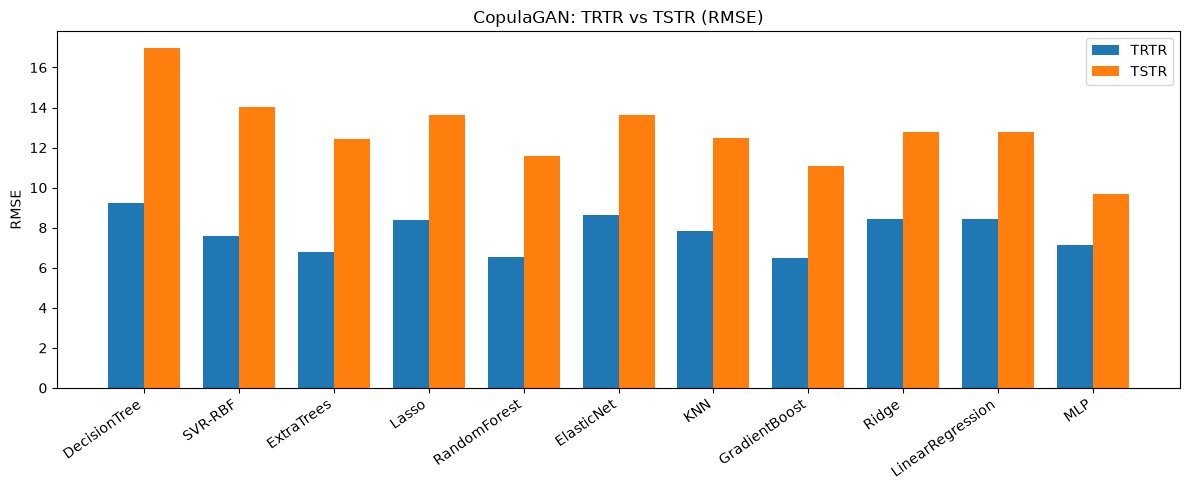

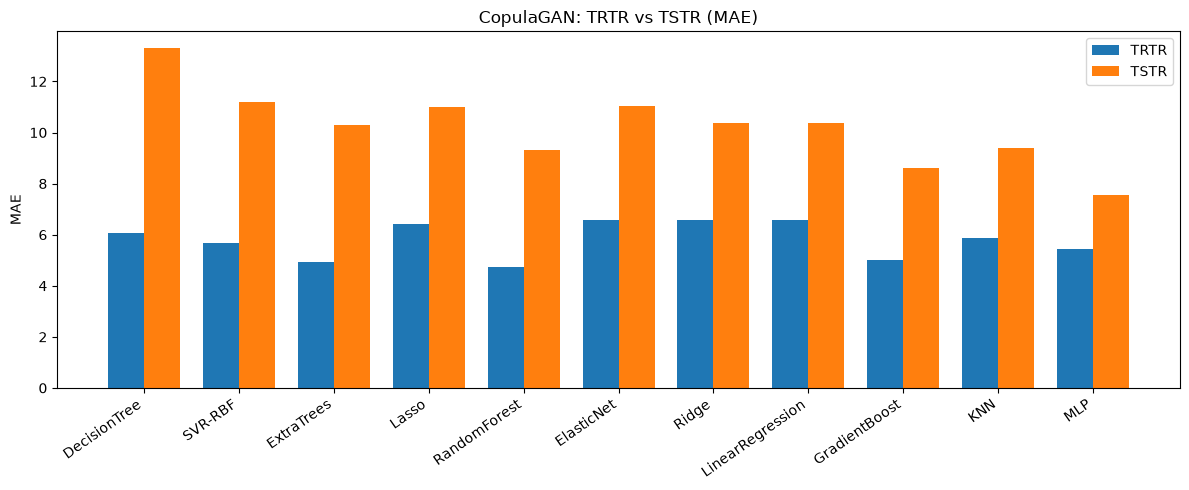

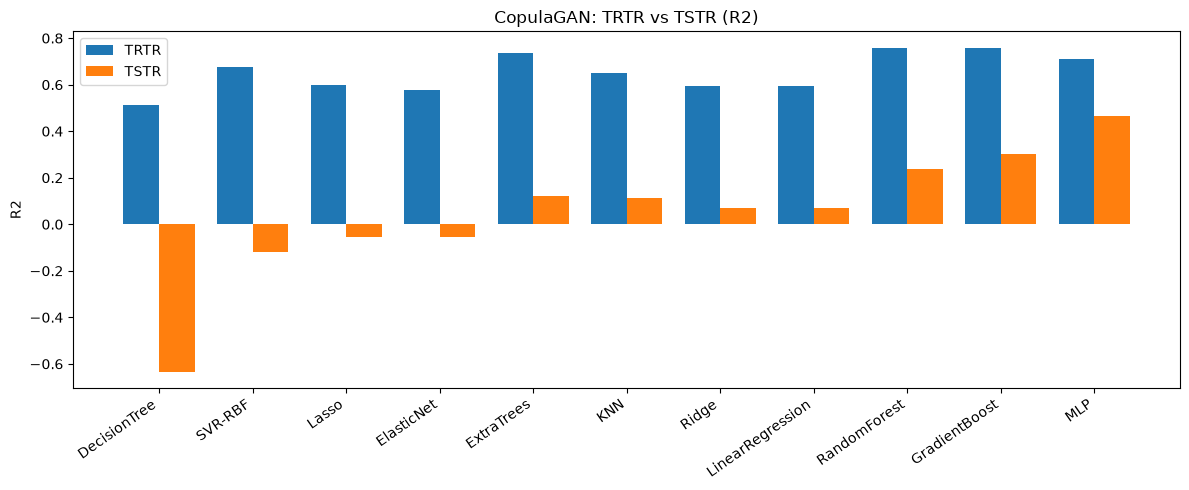

TVAE - TSTR


,Model,MAE,RMSE,R2
0,MLP,6.256711,8.083136,0.628736
1,Ridge,6.351328,8.096353,0.627520
2,LinearRegression,6.355325,8.097535,0.627412
3,Lasso,6.664353,8.426078,0.596564
4,ExtraTrees,6.793072,8.668389,0.573027
5,RandomForest,6.982747,8.797474,0.560216
6,ElasticNet,6.941071,8.812730,0.558689
7,KNN,6.801687,8.873491,0.552583
8,GradientBoost,7.339904,9.155935,0.523647
9,SVR-RBF,8.166157,10.217797,0.406749


TVAE - TRTR vs TSTR Comparison


,Model,MAE_TRTR,RMSE_TRTR,R2_TRTR,MAE_TSTR,RMSE_TSTR,R2_TSTR,RMSE_Diff,Synthetic_Model
0,GradientBoost,5.011186,6.503306,0.759679,7.339904,9.155935,0.523647,2.652630,TVAE
1,RandomForest,4.750236,6.542300,0.756788,6.982747,8.797474,0.560216,2.255174,TVAE
2,ExtraTrees,4.932865,6.800517,0.737211,6.793072,8.668389,0.573027,1.867872,TVAE
3,MLP,5.433684,7.122970,0.711699,6.256711,8.083136,0.628736,0.960165,TVAE
4,SVR-RBF,5.693551,7.573021,0.674117,8.166157,10.217797,0.406749,2.644776,TVAE
5,KNN,5.873494,7.828184,0.651786,6.801687,8.873491,0.552583,1.045308,TVAE
6,Lasso,6.414265,8.398341,0.599216,6.664353,8.426078,0.596564,0.027737,TVAE
7,Ridge,6.570079,8.439590,0.595269,6.351328,8.096353,0.627520,-0.343237,TVAE
8,LinearRegression,6.571629,8.440376,0.595194,6.355325,8.097535,0.627412,-0.342841,TVAE
9,ElasticNet,6.591839,8.610749,0.578686,6.941071,8.812730,0.558689,0.201981,TVAE


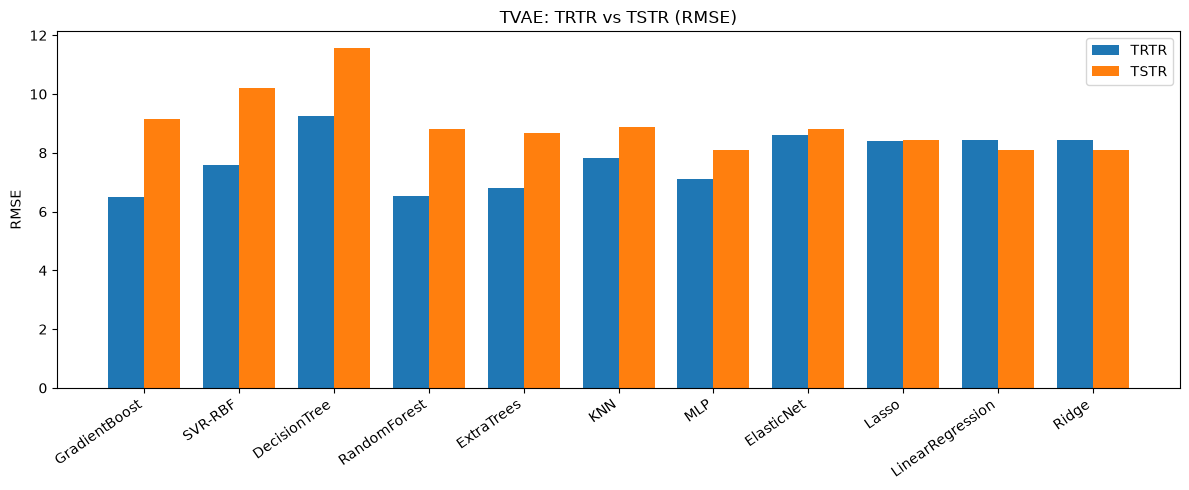

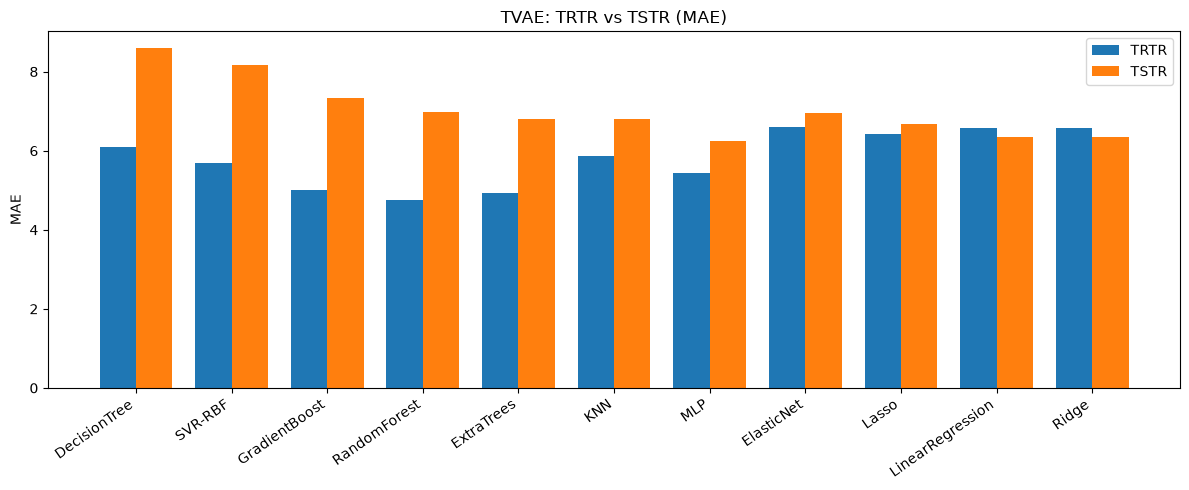

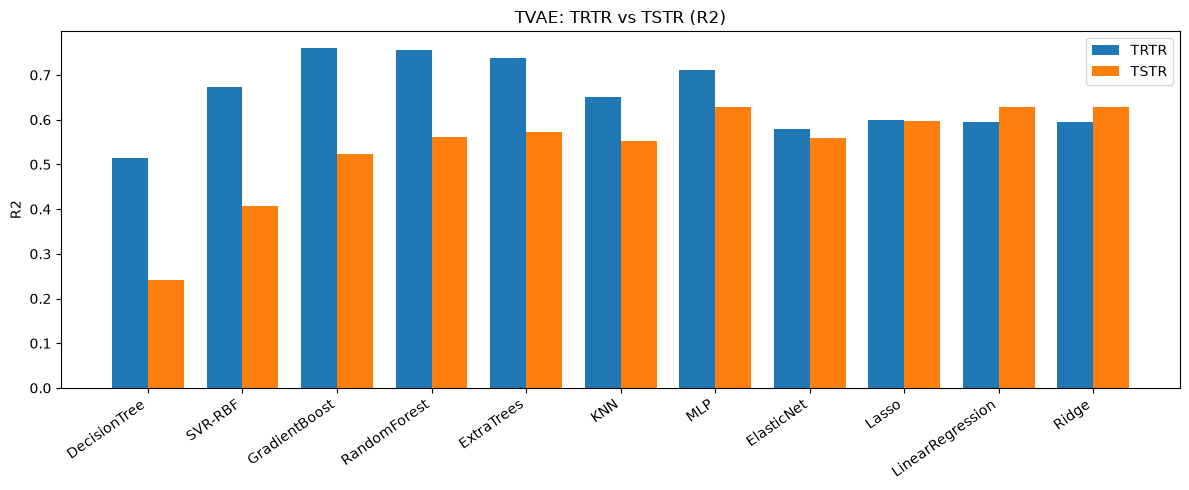

GaussianCopula - TSTR


,Model,MAE,RMSE,R2
0,MLP,6.190985,8.097883,0.627380
1,GradientBoost,5.966145,8.104971,0.626727
2,Lasso,6.599519,8.374790,0.601460
3,Ridge,6.821783,8.445590,0.594694
4,LinearRegression,6.828923,8.453304,0.593953
5,ElasticNet,6.678319,8.520672,0.587455
6,RandomForest,6.347614,8.681909,0.571694
7,SVR-RBF,6.922902,8.860621,0.553880
8,KNN,7.078795,9.172489,0.521923
9,ExtraTrees,6.909193,9.410422,0.496799


GaussianCopula - TRTR vs TSTR Comparison


,Model,MAE_TRTR,RMSE_TRTR,R2_TRTR,MAE_TSTR,RMSE_TSTR,R2_TSTR,RMSE_Diff,Synthetic_Model
0,GradientBoost,5.011186,6.503306,0.759679,5.966145,8.104971,0.626727,1.601666,GaussianCopula
1,RandomForest,4.750236,6.542300,0.756788,6.347614,8.681909,0.571694,2.139609,GaussianCopula
2,ExtraTrees,4.932865,6.800517,0.737211,6.909193,9.410422,0.496799,2.609905,GaussianCopula
3,MLP,5.433684,7.122970,0.711699,6.190985,8.097883,0.627380,0.974913,GaussianCopula
4,SVR-RBF,5.693551,7.573021,0.674117,6.922902,8.860621,0.553880,1.287600,GaussianCopula
5,KNN,5.873494,7.828184,0.651786,7.078795,9.172489,0.521923,1.344306,GaussianCopula
6,Lasso,6.414265,8.398341,0.599216,6.599519,8.374790,0.601460,-0.023552,GaussianCopula
7,Ridge,6.570079,8.439590,0.595269,6.821783,8.445590,0.594694,0.005999,GaussianCopula
8,LinearRegression,6.571629,8.440376,0.595194,6.828923,8.453304,0.593953,0.012928,GaussianCopula
9,ElasticNet,6.591839,8.610749,0.578686,6.678319,8.520672,0.587455,-0.090076,GaussianCopula


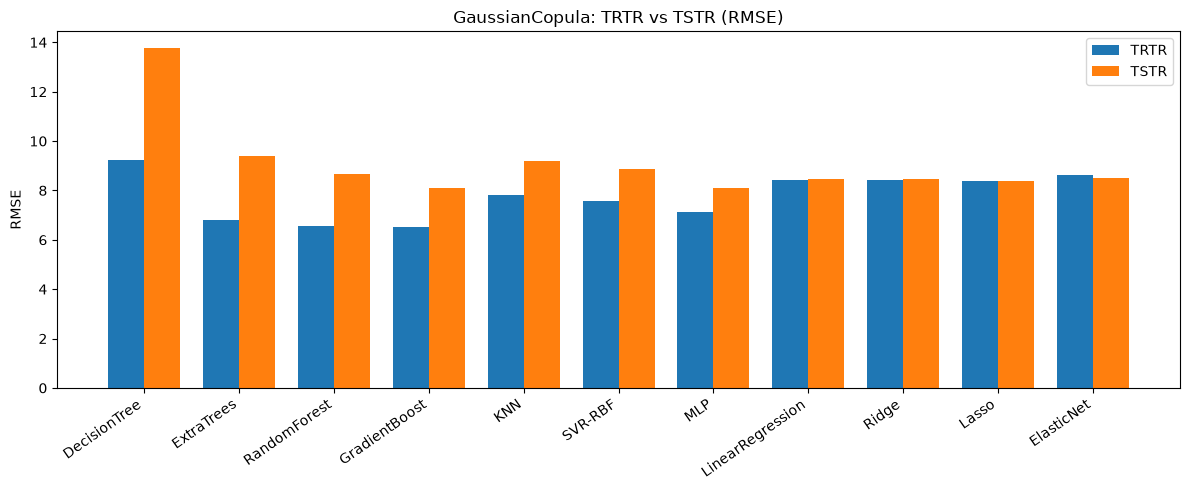

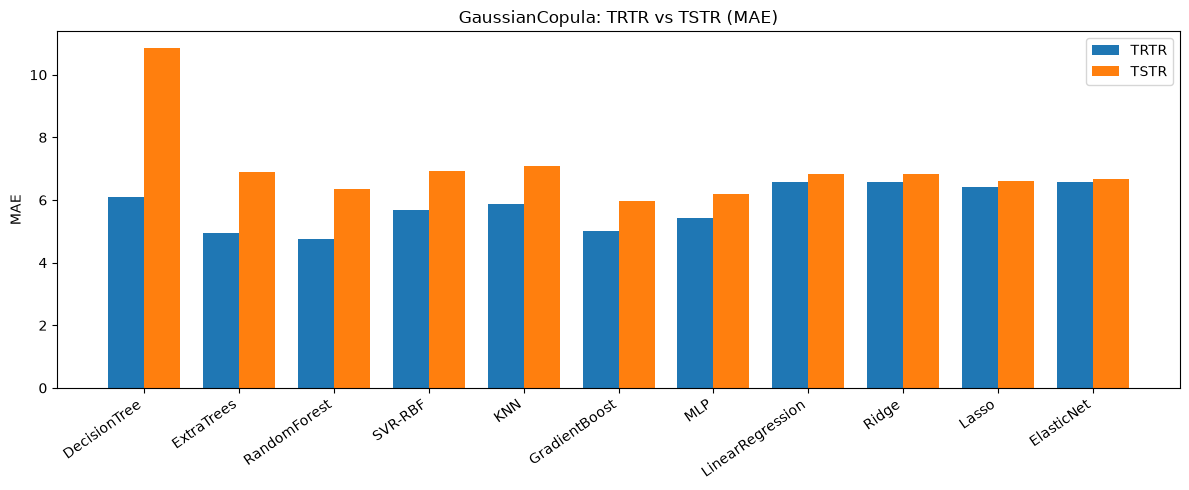

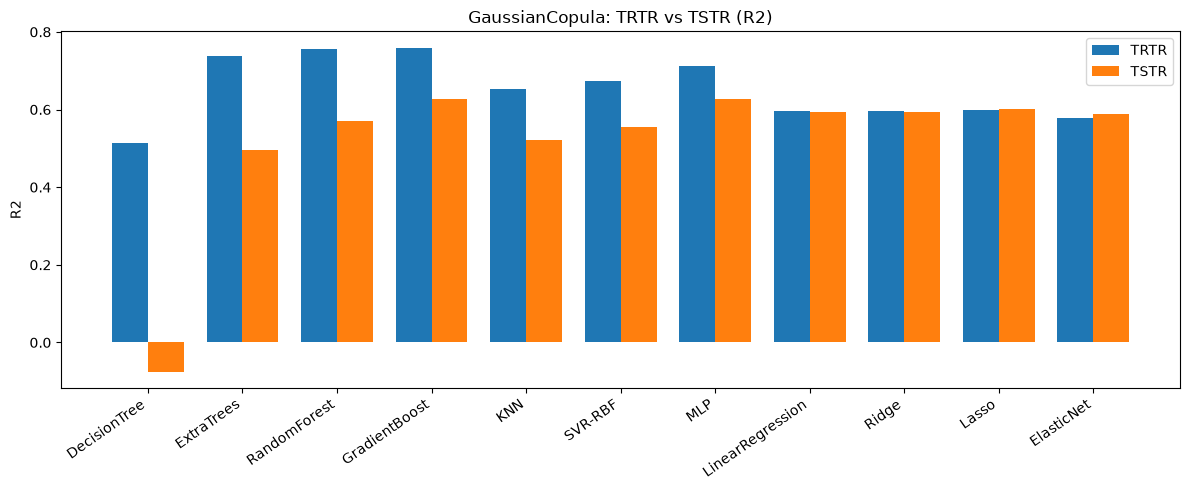

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="RMSE"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return
    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]], on="Model", suffixes=("_TRTR", "_TSTR")
    )
    df["Diff"] = (
        df[f"{metric}_TSTR"] - df[f"{metric}_TRTR"]
        if metric in ["MAE", "RMSE"]
        else df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    )
    df = df.sort_values("Diff", ascending=False)
    x = np.arange(len(df))
    w = 0.38
    plt.figure(figsize=(12, 5))
    plt.bar(x - w/2, df[f"{metric}_TRTR"], w, label="TRTR")
    plt.bar(x + w/2, df[f"{metric}_TSTR"], w, label="TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

label_col = "Y house price of unit area"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
trtr_results = evaluate_models(train_df=data, test_df=data, label=label_col, models=models)
print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)
for synth_name in model_order:
    _common = [c for c in data.columns if c in synthetic_datasets[synth_name].columns]
    synth_train = synthetic_datasets[synth_name][_common].copy()
    tstr_results = evaluate_models(train_df=synth_train, test_df=data, label=label_col, models=models)
    print(f"{synth_name} - TSTR")
    display(tstr_results)
    comparison = trtr_results.merge(tstr_results, on="Model", suffixes=("_TRTR", "_TSTR"))
    comparison["RMSE_Diff"] = comparison["RMSE_TSTR"] - comparison["RMSE_TRTR"]
    comparison["Synthetic_Model"] = synth_name
    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)
    for metric in ["RMSE", "MAE", "R2"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric)


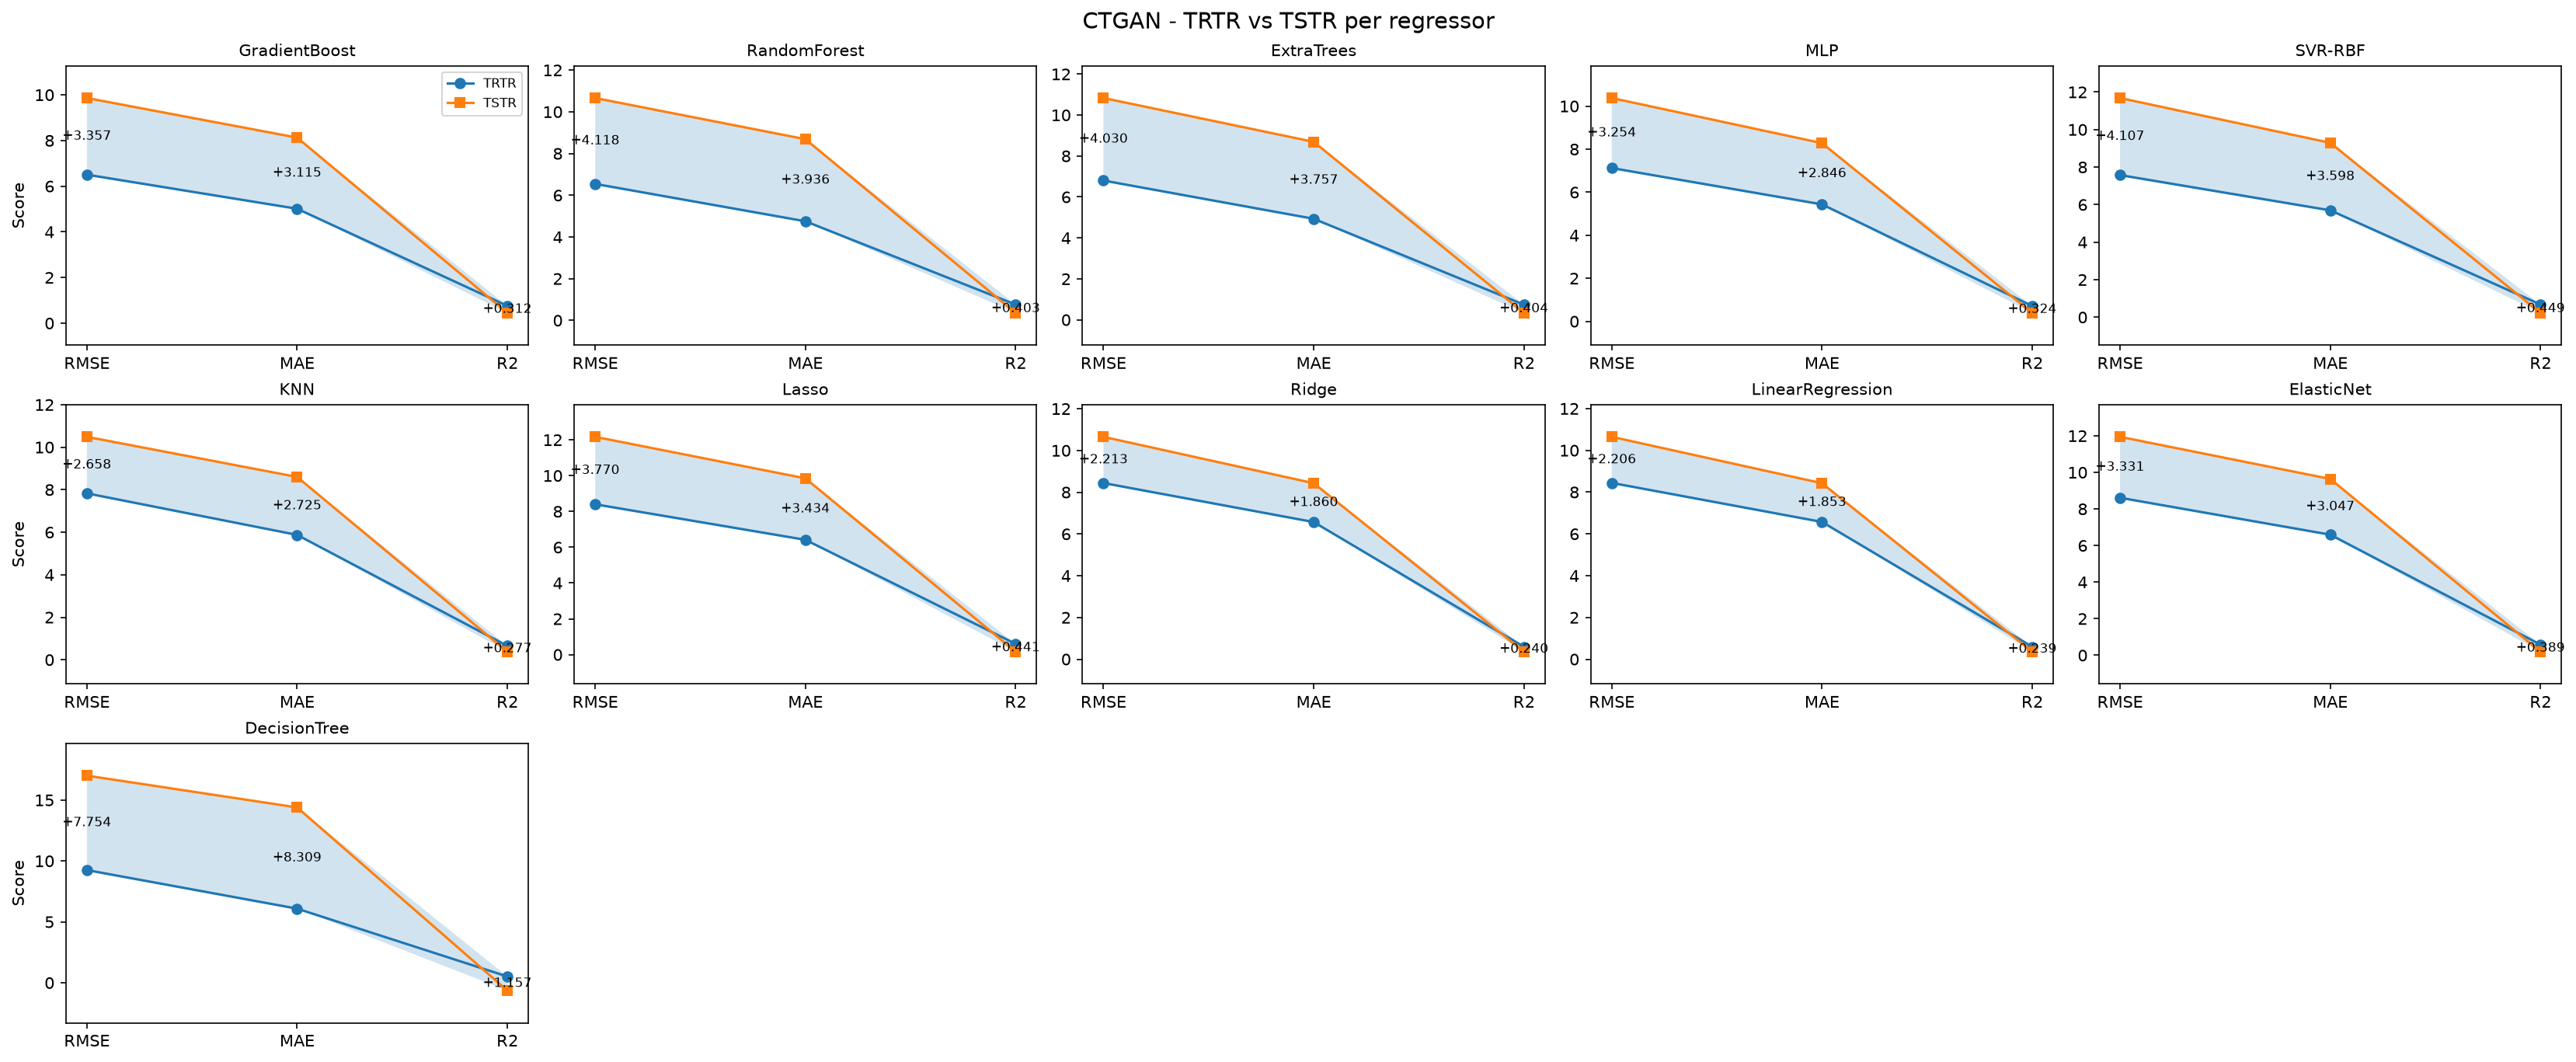

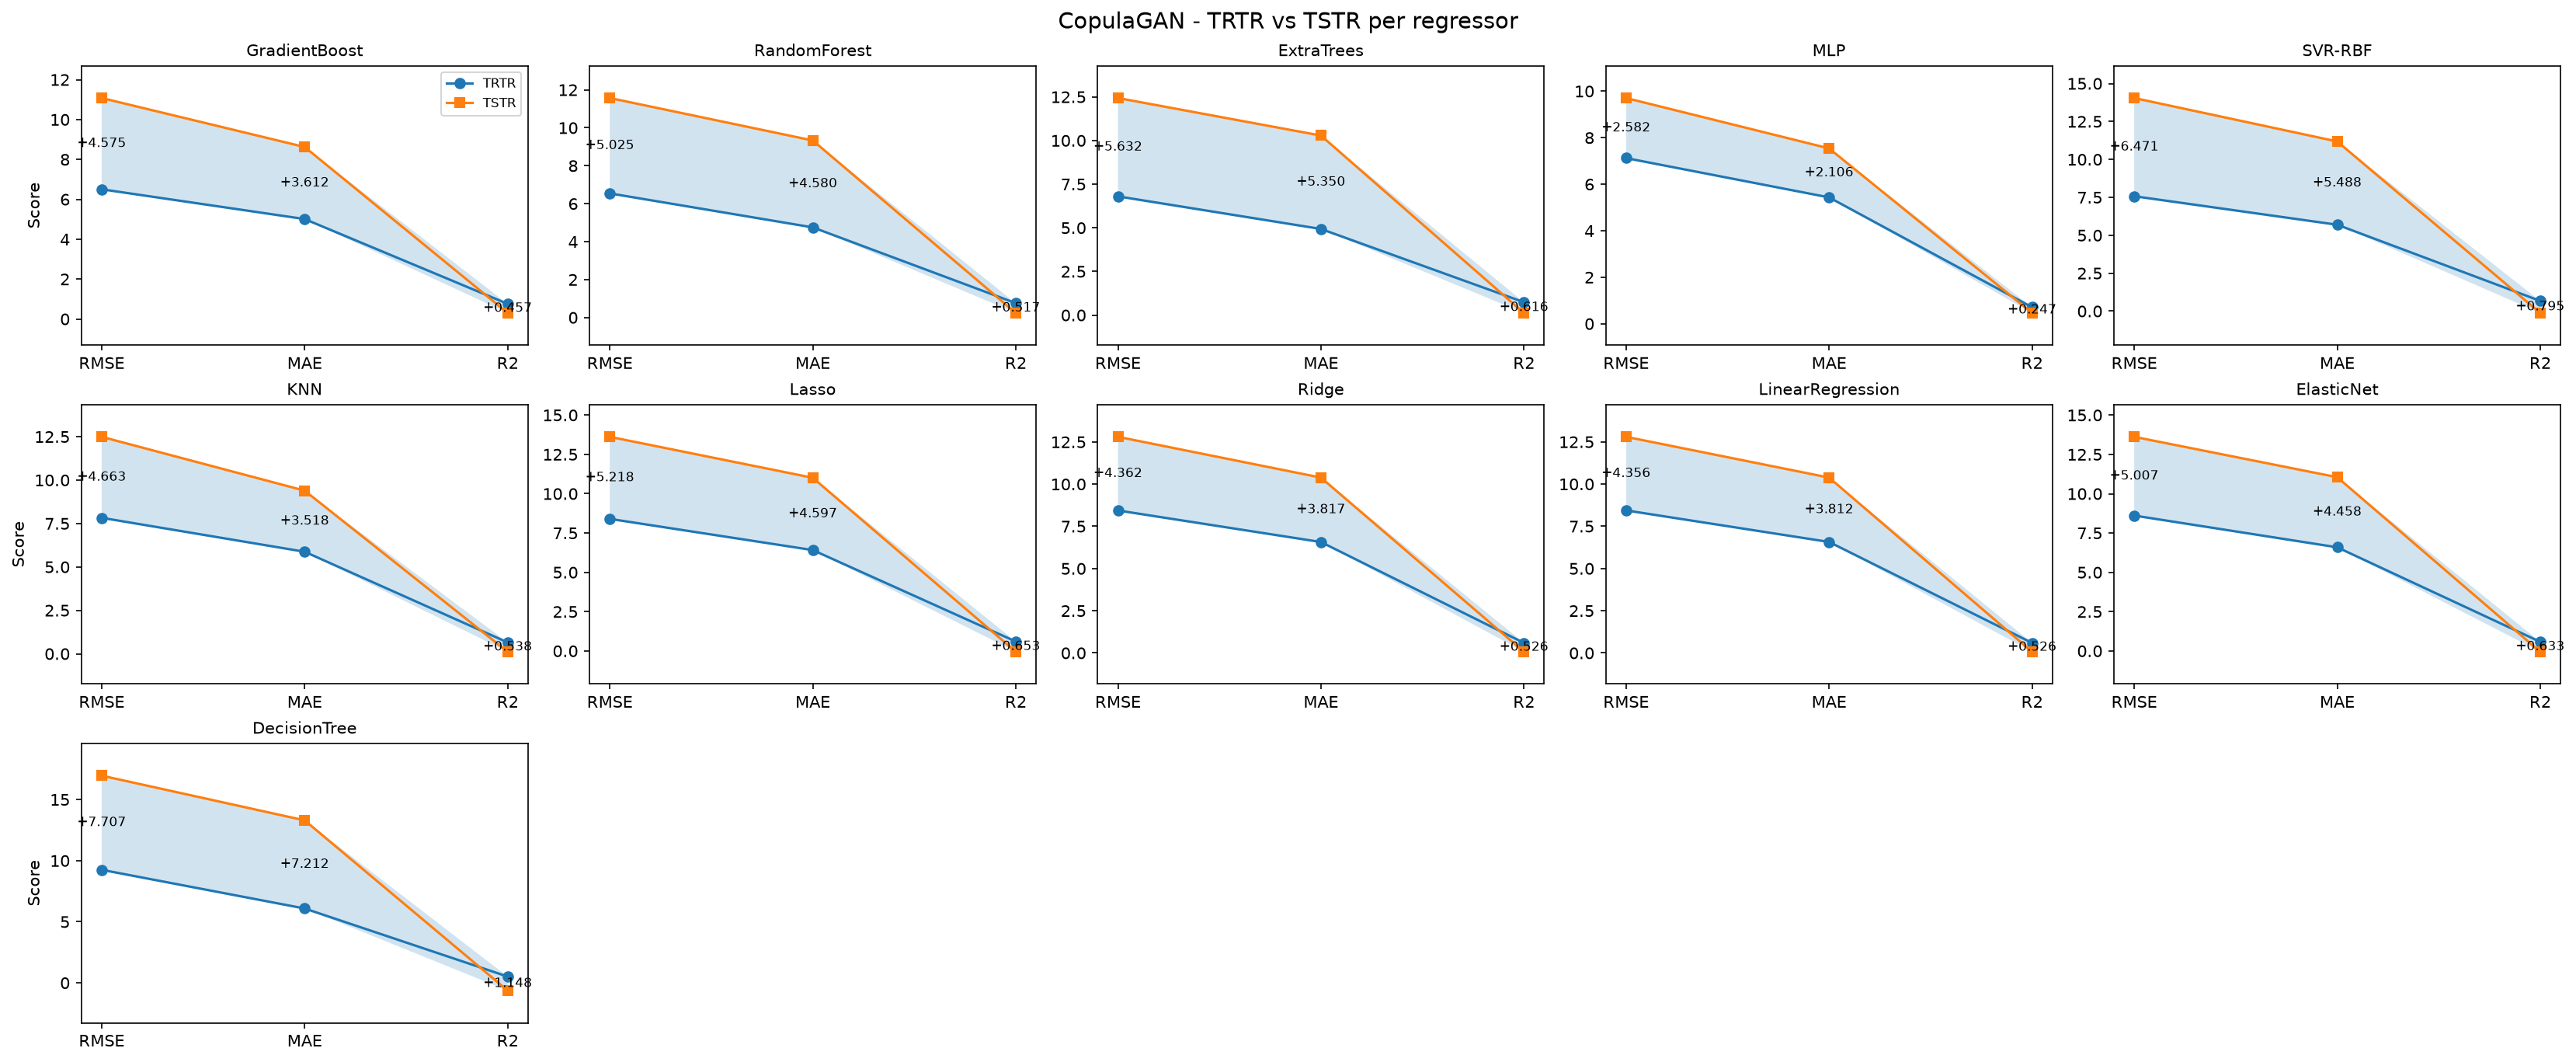

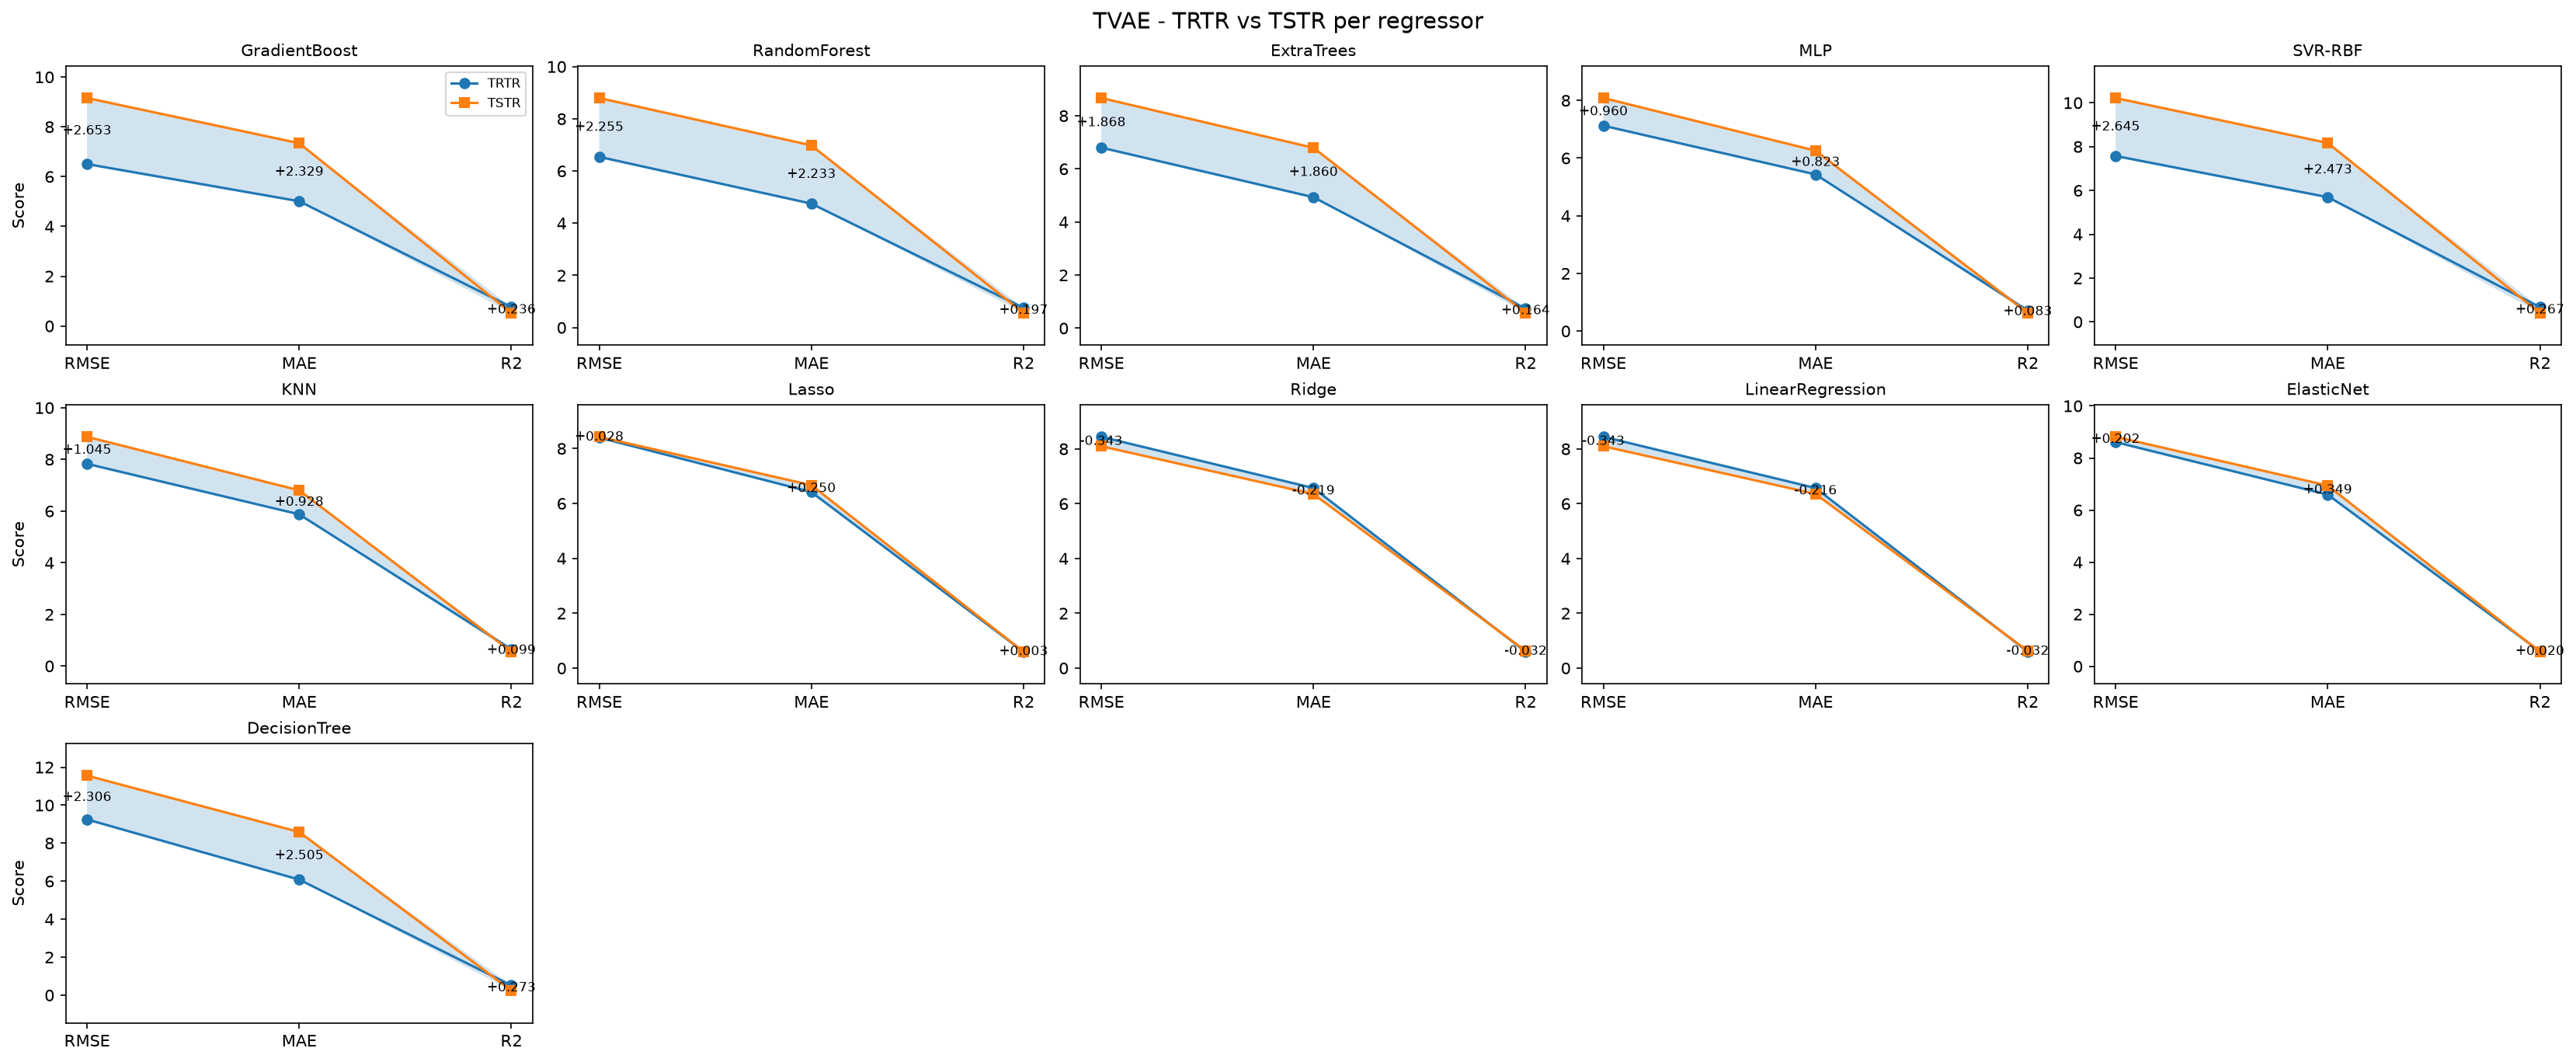

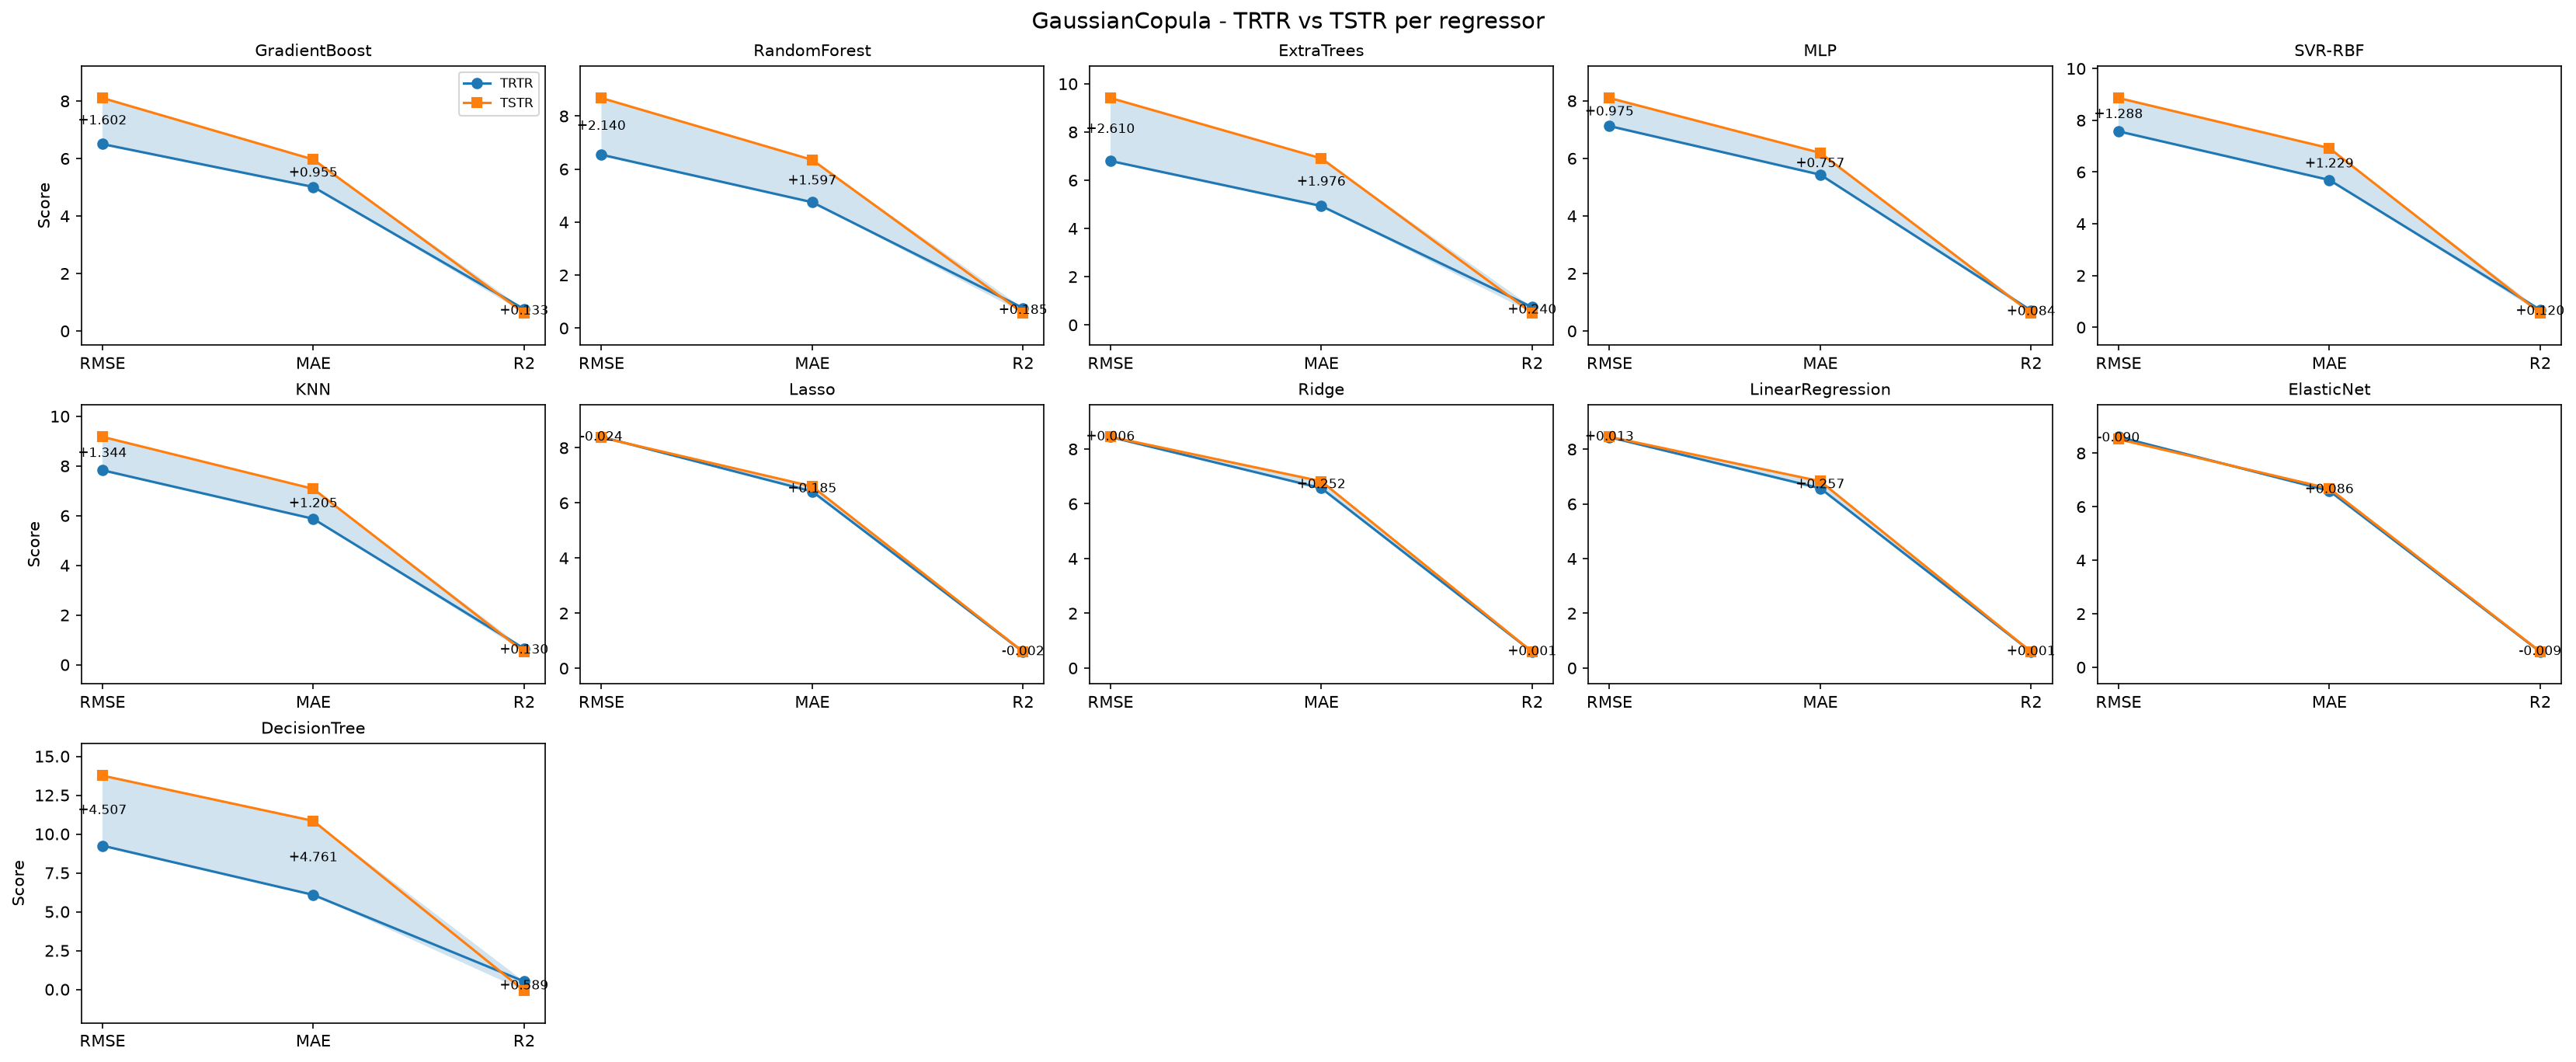

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def _metric_delta(metric, trtr_val, tstr_val):
    if metric in ("RMSE", "MAE"):
        return tstr_val - trtr_val
    if metric == "R2":
        return trtr_val - tstr_val
    return trtr_val - tstr_val

def plot_grid_line_metrics_with_gap(trtr_results, tstr_results, generator_name, ncols=5):
    metrics = [m for m in ["RMSE", "MAE", "R2"] if m in trtr_results.columns and m in tstr_results.columns]
    if not metrics:
        metrics = [m for m in ["Accuracy", "F1", "AUC"] if m in trtr_results.columns and m in tstr_results.columns]
    if not metrics:
        print(f"No common metrics found for {generator_name}.")
        return

    x = np.arange(len(metrics))
    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models_local = [m for m in trtr.index if m in tstr.index]

    n = len(models_local)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(22, max(9, 3 * nrows)), dpi=150, constrained_layout=True)
    axes = np.array(axes).reshape(-1)

    for i, model_name in enumerate(models_local):
        ax = axes[i]
        a = trtr.loc[model_name].values.astype(float)
        b = tstr.loc[model_name].values.astype(float)
        deltas = [_metric_delta(m, ai, bi) for m, ai, bi in zip(metrics, a, b)]

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="s", label="TSTR")
        ax.fill_between(x, np.minimum(a, b), np.maximum(a, b), alpha=0.2)

        lo = float(np.nanmin(np.concatenate([a, b])))
        hi = float(np.nanmax(np.concatenate([a, b])))
        pad = max((hi - lo) * 0.15, 0.05) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)

        for xi, ai, bi, di in zip(x, a, b, deltas):
            ax.text(xi, (ai + bi) / 2, f"{di:+.3f}", ha="center", va="center", fontsize=8)

        ax.set_title(model_name, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="best")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"{generator_name} - TRTR vs TSTR per regressor", fontsize=14)
    plt.show()

label_col = "Y house price of unit area"
generators = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
trtr_results = evaluate_models(train_df=data, test_df=data, label=label_col, models=models)
for gen in generators:
    _common = [c for c in data.columns if c in synthetic_datasets[gen].columns]
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[gen][_common],
        test_df=data,
        label=label_col,
        models=models,
    )
    plot_grid_line_metrics_with_gap(trtr_results, tstr_results, generator_name=gen, ncols=5)


# 5 Statistical similarity tests 

Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,55.159242,31.150442,225321.091310
1,CopulaGAN,71.639749,98.298639,225335.064498
2,TVAE,49.869909,30.284629,225327.474610
3,GaussianCopula,54.663140,36.106195,225317.097874


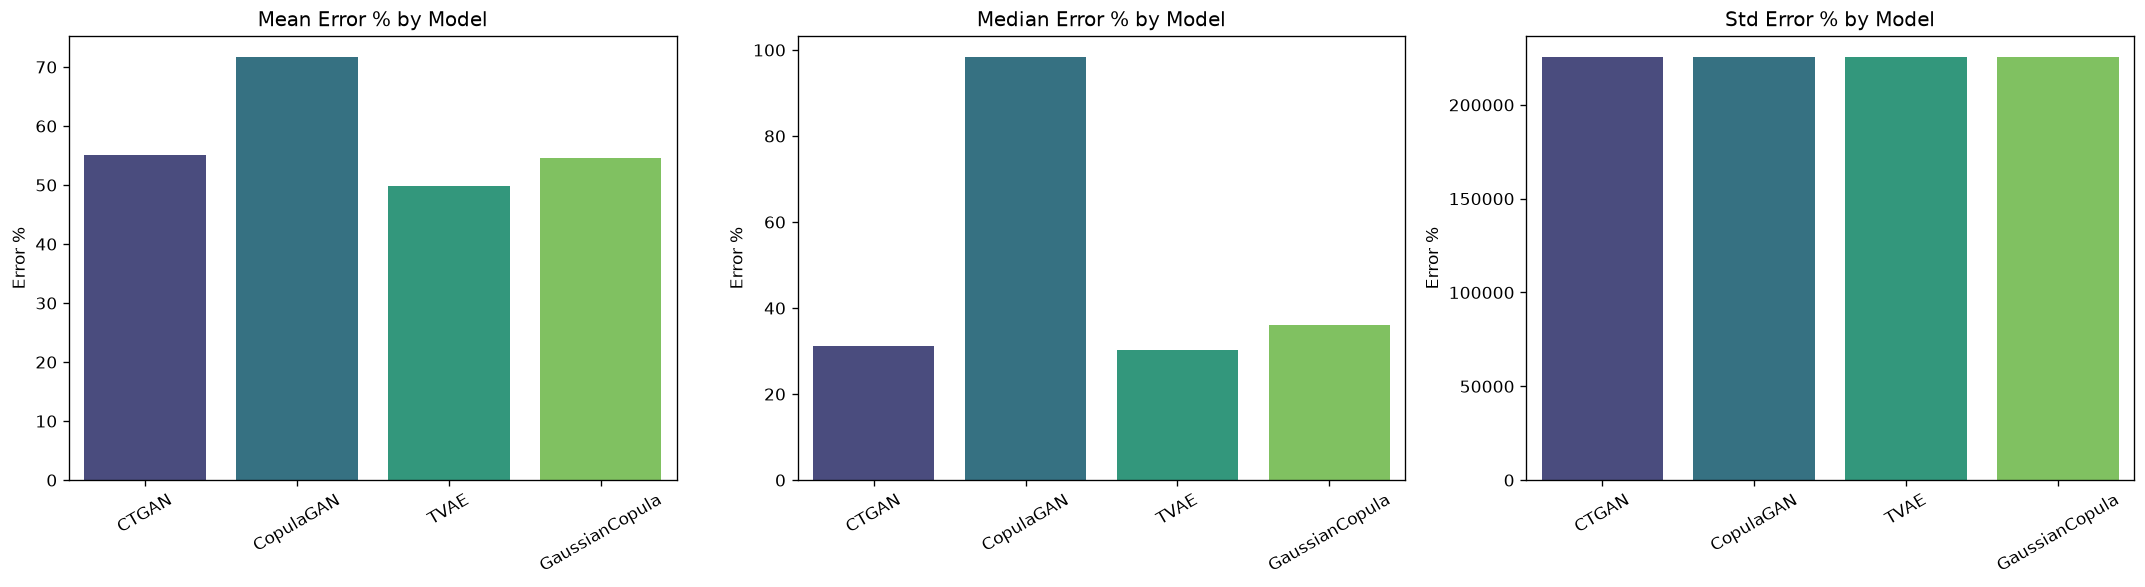

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "Y house price of unit area"]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_means = real_df[num_cols].astype(np.float64).mean()
    synth_means = synth_df[num_cols].astype(np.float64).mean()

    real_stds = real_df[num_cols].astype(np.float64).std(ddof=1)
    synth_stds = synth_df[num_cols].astype(np.float64).std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    })

    feature_error_df = feature_error_df.replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True))
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


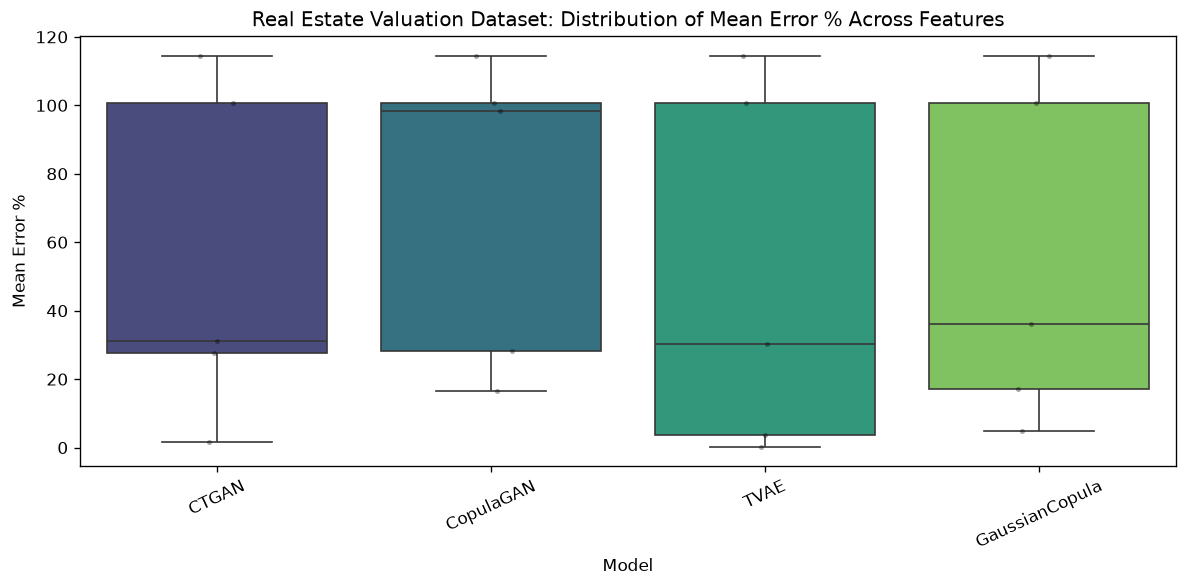

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Real Estate Valuation Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

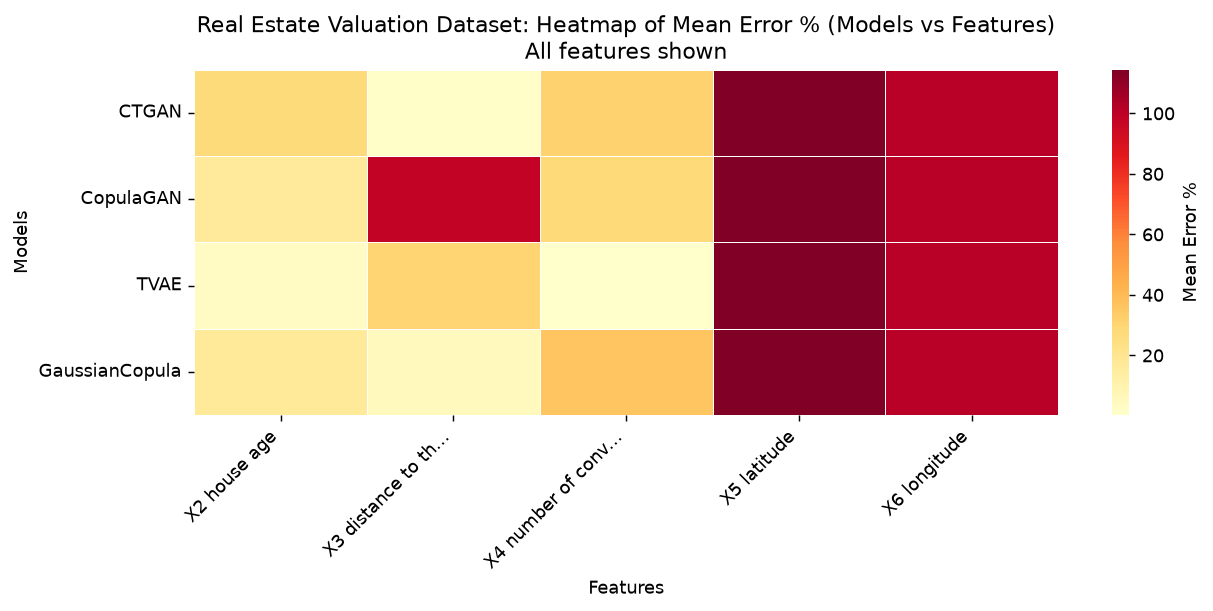

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Real Estate Valuation Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

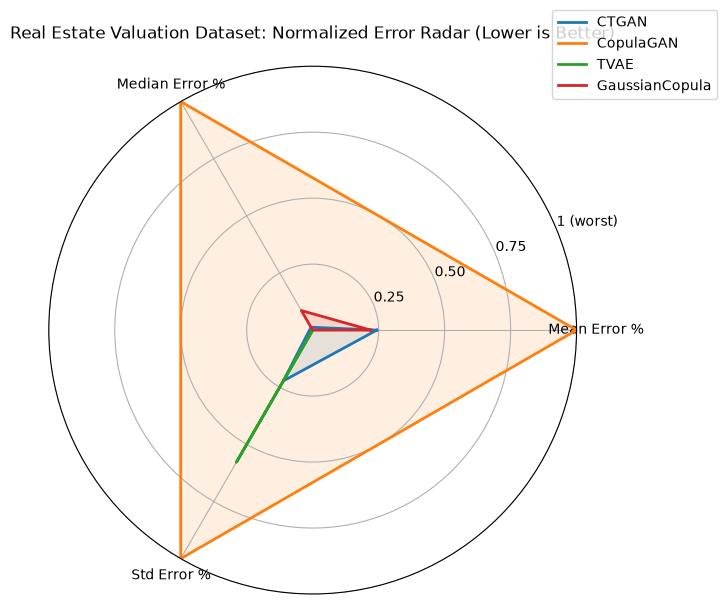

,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,0.242966,0.012730,0.222270
1,CopulaGAN,1.000000,1.000000,1.000000
2,TVAE,0.000000,0.000000,0.577556
3,GaussianCopula,0.220178,0.085594,0.000000


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metrics = ["Mean Error %", "Median Error %", "Std Error %"]
radar_df = summary_df[["Model"] + metrics].copy()

norm_df = radar_df.copy()
for m in metrics:
    mn, mx = norm_df[m].min(), norm_df[m].max()
    if mx > mn:
        norm_df[m] = (norm_df[m] - mn) / (mx - mn)
    else:
        norm_df[m] = 0.0

labels = metrics
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for _, row in norm_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0 (best)", "0.25", "0.50", "0.75", "1 (worst)"])
ax.set_title("Real Estate Valuation Dataset: Normalized Error Radar (Lower is Better)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12))

plt.tight_layout()
plt.show()

display(norm_df)

Average absolute difference in outlier counts (Real vs Synthetic) by model:


,Model,Avg_Abs_Diff_Outlier_Count,Median_Abs_Diff_Outlier_Count,Max_Abs_Diff_Outlier_Count
0,GaussianCopula,9.4,4.0,35.0
1,CTGAN,15.6,15.0,35.0
2,CopulaGAN,16.0,8.0,37.0
3,TVAE,29.0,19.0,83.0


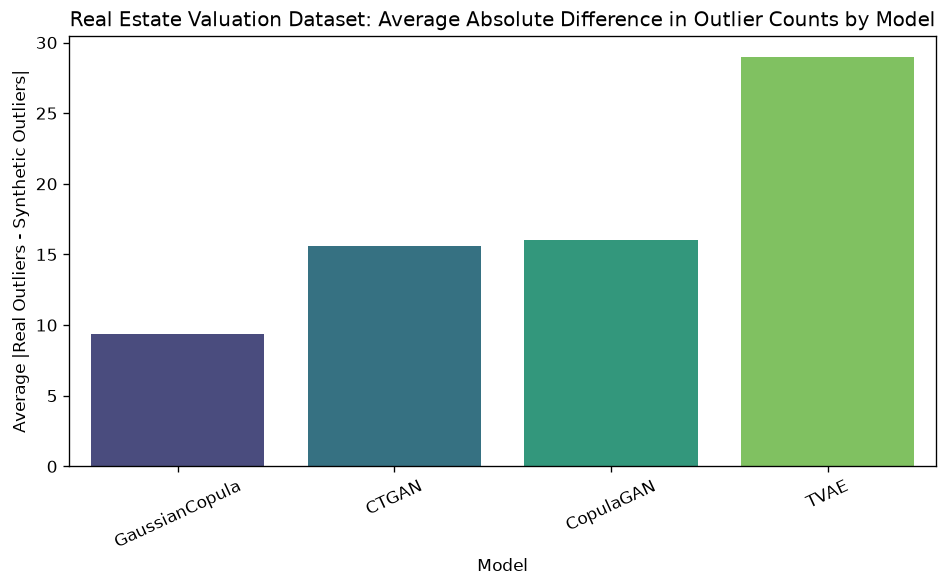

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "Y house price of unit area"]

def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

real_outliers = {c: outlier_count_iqr(real_df[c]) for c in num_cols}

for model in model_order:
    synth_df = synthetic_datasets[model][real_df.columns].copy()
    synth_outliers = {c: outlier_count_iqr(synth_df[c]) for c in num_cols}

    feat_df = pd.DataFrame({
        "Feature": num_cols,
        "Real_Outliers": [real_outliers[c] for c in num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in num_cols]
    })
    feat_df["Abs_Diff_Outlier_Count"] = (feat_df["Real_Outliers"] - feat_df["Synthetic_Outliers"]).abs()

    feature_diff_by_model[model] = feat_df
    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].mean()),
        "Median_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].median()),
        "Max_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].max())
    })

outlier_summary_df = pd.DataFrame(rows).sort_values("Avg_Abs_Diff_Outlier_Count").reset_index(drop=True)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=outlier_summary_df, x="Model", y="Avg_Abs_Diff_Outlier_Count", palette="viridis")
plt.title("Real Estate Valuation Dataset: Average Absolute Difference in Outlier Counts by Model")
plt.xlabel("Model")
plt.ylabel("Average |Real Outliers - Synthetic Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


# 6. Cosine Similarity with Hungraian Mapping

In [31]:
from numpy.linalg import norm
import numpy as np
import pandas as pd
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer

if "ctgan" not in globals():
    ctgan = CTGANSynthesizer(metadata=metadata)
    ctgan.fit(data)

if "copulagan" not in globals():
    copulagan = CopulaGANSynthesizer(metadata=metadata)
    copulagan.fit(data)

if "tvae" not in globals():
    tvae = TVAESynthesizer(metadata=metadata)
    tvae.fit(data)

if "gaussiancopula" not in globals():
    gaussiancopula = GaussianCopulaSynthesizer(metadata=metadata)
    gaussiancopula.fit(data)

synth_models = {
    "CTGAN": ctgan,
    "CopulaGAN": copulagan,
    "TVAE": tvae,
    "GaussianCopula": gaussiancopula
}

n_rows = len(data)
synthetic_data = {}
for name, synth in synth_models.items():
    synthetic_data[name] = synth.sample(num_rows=n_rows)[data.columns]

def normalize_rows(X):
    X = np.asarray(X, dtype=np.float64)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

cosine_results = {}
cosine_dfs = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "Y house price of unit area"]

real_matrix = normalize_rows(data[num_cols].to_numpy(dtype=np.float64))

for model_name, synth_df in synthetic_data.items():
    print(f"Building cosine similarity DataFrame for {model_name}...")

    synth_matrix = normalize_rows(synth_df[num_cols].to_numpy(dtype=np.float64))
    cosine_matrix = real_matrix @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max())
    }

    print(cosine_df, "\n")

display(pd.DataFrame(cosine_results).T)


Building cosine similarity DataFrame for CTGAN...
           S1        S2        S3        S4        S5        S6        S7  \
R1   0.730377  0.937833  0.852113  0.796250  0.872139  0.846601  0.840797   
R2   0.909333  0.878055  0.974058  0.946646  0.982301  0.971601  0.968947   
R3   0.821370  0.920887  0.918897  0.875252  0.933721  0.914753  0.910293   
R4   0.687784  0.942831  0.818321  0.757731  0.840693  0.812122  0.805699   
R5   0.971481  0.796642  0.999281  0.990190  0.999916  0.998852  0.998236   
R6   0.891579  0.893687  0.962886  0.931972  0.972881  0.959902  0.956829   
R7   0.832091  0.922293  0.925649  0.883748  0.940067  0.921538  0.917250   
R8   0.832062  0.922360  0.925610  0.883710  0.940034  0.921496  0.917208   
R9   0.958092  0.822755  0.995873  0.981781  0.998655  0.994852  0.993663   
R10  0.433059  0.892889  0.603632  0.522472  0.634936  0.595144  0.586462   

           S8        S9       S10  
R1   0.815046  0.898015  0.765743  
R2   0.956819  0.991223  0.926

,avg_cosine,max_cosine
CTGAN,0.856871,1.000000
CopulaGAN,0.738930,1.000000
TVAE,0.840121,0.999993
GaussianCopula,0.827116,0.999999


In [32]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

def normalize_rows(X):
    X = np.asarray(X, dtype=np.float64)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()
    num_cols = [c for c in num_cols if c != "Y house price of unit area"]

    R = real_data[num_cols].to_numpy(dtype=np.float64)
    S = synthetic_data[num_cols].to_numpy(dtype=np.float64)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = data.copy()
results = {}

for name, synth_df in synthetic_data.items():
    synth_df = synth_df[data.columns].copy()
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. R{i+1} -> S{best_indices[i]+1}   cosine similarity = {best_sims[i]:.4f}")



CTGAN - Top 10 Real -> Synthetic Matchings
01. R129 -> S303   cosine similarity = 1.0000
02. R150 -> S127   cosine similarity = 1.0000
03. R383 -> S303   cosine similarity = 1.0000
04. R275 -> S303   cosine similarity = 1.0000
05. R108 -> S310   cosine similarity = 1.0000
06. R197 -> S257   cosine similarity = 1.0000
07. R115 -> S257   cosine similarity = 1.0000
08. R168 -> S303   cosine similarity = 1.0000
09. R25 -> S303   cosine similarity = 1.0000
10. R232 -> S303   cosine similarity = 1.0000

CopulaGAN - Top 10 Real -> Synthetic Matchings
01. R127 -> S303   cosine similarity = 1.0000
02. R122 -> S303   cosine similarity = 1.0000
03. R314 -> S303   cosine similarity = 1.0000
04. R203 -> S303   cosine similarity = 1.0000
05. R378 -> S303   cosine similarity = 1.0000
06. R286 -> S303   cosine similarity = 1.0000
07. R403 -> S303   cosine similarity = 1.0000
08. R243 -> S303   cosine similarity = 1.0000
09. R27 -> S303   cosine similarity = 1.0000
10. R273 -> S303   cosine similarity

In [33]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

def normalize_rows(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != "Y house price of unit area"]

    R = real_df[num_cols].to_numpy(dtype=np.float64)
    S = synth_df[num_cols].to_numpy(dtype=np.float64)
    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

real_df = data.copy()
results = {}

for name in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, numeric features excluding quality)")
    print(f"==============================")

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")



CTGAN: Hungarian matching (cosine, numeric features excluding quality)
Average cosine similarity (Hungarian match): 0.9169

R195 <-> S362   cosine similarity = 0.9913
R83 <-> S107   cosine similarity = 0.9912
R289 <-> S88   cosine similarity = 0.9912
R70 <-> S290   cosine similarity = 0.9909
R261 <-> S59   cosine similarity = 0.9906
R175 <-> S20   cosine similarity = 0.9905
R279 <-> S397   cosine similarity = 0.9904
R120 <-> S8   cosine similarity = 0.9904
R194 <-> S113   cosine similarity = 0.9904
R58 <-> S81   cosine similarity = 0.9902

CopulaGAN: Hungarian matching (cosine, numeric features excluding quality)
Average cosine similarity (Hungarian match): 0.8511

R359 <-> S332   cosine similarity = 0.9983
R84 <-> S152   cosine similarity = 0.9974
R388 <-> S160   cosine similarity = 0.9971
R124 <-> S94   cosine similarity = 0.9950
R224 <-> S9   cosine similarity = 0.9944
R3 <-> S110   cosine similarity = 0.9944
R169 <-> S212   cosine similarity = 0.9943
R118 <-> S127   cosine similar

In [34]:
import pandas as pd
import numpy as np

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "Y house price of unit area"]

if "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found. Expected `synthetic_data` or `synthetic_tables`.")

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
output_file = "Hungarian_Matchings_All_Models_RealEstate.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results or model_name not in synth_source:
            continue

        row_ind = results[model_name]["row_ind"]
        col_ind = results[model_name]["col_ind"]

        if "similarities" in results[model_name]:
            score_key = "cosine_similarity"
            scores = results[model_name]["similarities"]
        elif "distances" in results[model_name]:
            score_key = "mahalanobis_distance"
            scores = results[model_name]["distances"]
        else:
            raise KeyError(f"No score array found for model {model_name}. Expected 'similarities' or 'distances'.")

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            score_key: scores
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name][real_df.columns].copy()
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        side_by_side.to_excel(writer, sheet_name=model_name[:31], index=False)
        combined_rows.append(side_by_side)

        summary_row = {
            "Model": model_name,
            "Num_Matches": len(scores),
            f"Avg_{score_key}": float(np.mean(scores)),
            f"Median_{score_key}": float(np.median(scores)),
            f"Min_{score_key}": float(np.min(scores)),
            f"Max_{score_key}": float(np.max(scores)),
        }
        summary_rows.append(summary_row)

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows)
        sort_col = [c for c in summary_df.columns if c.startswith("Avg_")][0]
        ascending = False if "cosine" in sort_col else True
        summary_df = summary_df.sort_values(sort_col, ascending=ascending)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)

print(f"Saved: {output_file}")
display(summary_df)


Saved: Hungarian_Matchings_All_Models_RealEstate.xlsx


,Model,Num_Matches,Avg_cosine_similarity,Median_cosine_similarity,Min_cosine_similarity,Max_cosine_similarity
2,TVAE,414,0.923217,0.962943,0.115926,0.999159
0,CTGAN,414,0.916909,0.959521,0.123460,0.991338
3,GaussianCopula,414,0.903370,0.957922,0.158023,0.998246
1,CopulaGAN,414,0.851143,0.951381,0.192983,0.998309


# 7. Mahalanobis distance with Hungrain Mapping  

In [35]:
import numpy as np
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "Y house price of unit area"]

data_numeric = data[num_cols].dropna().copy()
real_matrix = data_numeric.to_numpy(dtype=np.float64)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real feature data.")
print(f"Used features: {len(num_cols)}")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")


Fitted mean and inverse covariance on real feature data.
Used features: 5
Mean shape: (5,), Inv_cov shape: (5, 5)


In [36]:
mahalanobis_results = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "Y house price of unit area"]

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][num_cols].copy()
    synth_numeric = synth_df.to_numpy(dtype=np.float64)

    dists = mahalanobis_distances_to_distribution(synth_numeric, mu_real, inv_cov_real)

    mahalanobis_results[name] = {
        "mean": float(np.mean(dists)),
        "median": float(np.median(dists)),
        "std": float(np.std(dists)),
        "min": float(np.min(dists)),
        "max": float(np.max(dists)),
        "distances": dists,
    }

summary = pd.DataFrame({
    name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
    for name, r in mahalanobis_results.items()
}, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T

summary.index.name = "Model"
summary = summary.sort_values("mean_dist")

print("Mahalanobis distance to real distribution (lower is better):")
display(summary)


Mahalanobis distance to real distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
CTGAN,16693.620558,14914.893485,9653.758463,969.009979,34799.967585
GaussianCopula,16694.422017,14914.767712,9654.189891,968.428083,34802.845273
TVAE,16694.657322,14914.735618,9654.243224,968.792213,34801.487516
CopulaGAN,16694.702693,14911.003184,9654.310792,968.392156,34802.896734


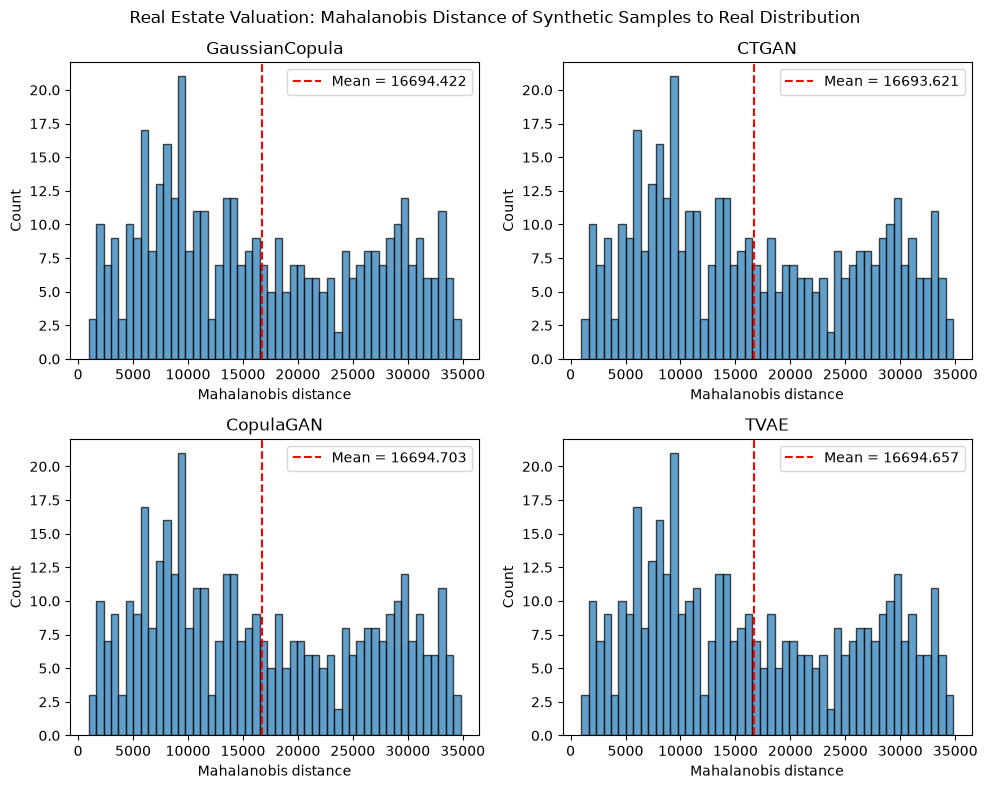

In [37]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(res["mean"], color="red", linestyle="--", label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle("Real Estate Valuation: Mahalanobis Distance of Synthetic Samples to Real Distribution", fontsize=12)
plt.tight_layout()

ROOT = os.getcwd()
fig_dir = os.path.join(ROOT, "figures")
os.makedirs(fig_dir, exist_ok=True)

plt.savefig(
    os.path.join(fig_dir, "mahalanobis_realestate_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()


In [38]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

hungarian_results = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "Y house price of unit area"]

real_matrix = data[num_cols].to_numpy(dtype=np.float64)
n_samples = len(real_matrix)

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name][num_cols].to_numpy(dtype=np.float64)
    assert synth_numeric.shape[0] == n_samples, (
        f"Synthetic size {synth_numeric.shape[0]} != real size {n_samples}"
    )

    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    row_ind, col_ind = linear_sum_assignment(D)
    matched_distances = D[row_ind, col_ind]

    hungarian_results[name] = {
        "total_distance": float(matched_distances.sum()),
        "mean_distance_per_match": float(matched_distances.mean()),
        "median_distance_per_match": float(np.median(matched_distances)),
        "std_distance_per_match": float(np.std(matched_distances)),
        "max_distance_per_match": float(matched_distances.max()),
        "matched_distances": matched_distances,
        "row_ind": row_ind,
        "col_ind": col_ind,
    }

hungarian_summary = pd.DataFrame(
    {
        name: [
            r["mean_distance_per_match"],
            r["median_distance_per_match"],
            r["std_distance_per_match"],
            r["max_distance_per_match"],
        ]
        for name, r in hungarian_results.items()
    },
    index=[
        "mean_distance_per_match",
        "median_distance_per_match",
        "std_distance_per_match",
        "max_distance_per_match",
    ],
).T

hungarian_summary.index.name = "Model"
hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

print("Hungarian matching using Mahalanobis distance (lower is better):")
display(hungarian_summary)


Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match
Model,,,,
CTGAN,16692.752234,14914.353175,9654.142647,34799.950708
GaussianCopula,16693.553751,14913.680046,9654.578142,34803.000426
TVAE,16693.789109,14913.648038,9654.601568,34800.988092
CopulaGAN,16693.834433,14909.915092,9654.691532,34802.397366


In [39]:
import numpy as np
import pandas as pd

def greedy_one_to_one_matching_fast(D):
    n_rows, n_cols = D.shape
    n_match = min(n_rows, n_cols)

    used_rows = np.zeros(n_rows, dtype=bool)
    used_cols = np.zeros(n_cols, dtype=bool)

    flat_order = np.argsort(D, axis=None)
    pairs = []

    for idx in flat_order:
        i = idx // n_cols
        j = idx % n_cols
        if not used_rows[i] and not used_cols[j]:
            used_rows[i] = True
            used_cols[j] = True
            pairs.append((i, j, float(D[i, j])))
            if len(pairs) == n_match:
                break

    distances = np.array([p[2] for p in pairs], dtype=np.float64)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

greedy_results = {}
comparison_rows = []

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "Y house price of unit area"]

X_real_full = data[num_cols].to_numpy(dtype=np.float64)

MAX_ROWS = 2000
rng = np.random.default_rng(42)

if len(X_real_full) > MAX_ROWS:
    real_idx = rng.choice(len(X_real_full), size=MAX_ROWS, replace=False)
else:
    real_idx = np.arange(len(X_real_full))

X_real = X_real_full[real_idx]

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    X_synth_full = synthetic_data[name][num_cols].to_numpy(dtype=np.float64)

    if len(X_synth_full) > MAX_ROWS:
        synth_idx = rng.choice(len(X_synth_full), size=MAX_ROWS, replace=False)
    else:
        synth_idx = np.arange(len(X_synth_full))

    X_synth = X_synth_full[synth_idx]

    D = pairwise_mahalanobis(X_real, X_synth, inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    total_g, mean_g, _ = greedy_one_to_one_matching_fast(D)

    greedy_results[name] = {
        "total_distance": total_g,
        "mean_distance": mean_g
    }

    h_total = hungarian_results[name]["total_distance"]
    h_mean = hungarian_results[name]["mean_distance_per_match"]

    comparison_rows.append({
        "Model": name,
        "Rows_Used_For_Greedy": int(min(len(X_real), len(X_synth))),
        "Greedy total (sampled)": total_g,
        "Hungarian total (full)": h_total,
        "Greedy mean (sampled)": mean_g,
        "Hungarian mean (full)": h_mean,
        "Total diff": total_g - h_total,
        "Mean diff": mean_g - h_mean,
    })

greedy_summary = pd.DataFrame({
    name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
    for name in greedy_results
}, index=["total_distance", "mean_distance"]).T
greedy_summary.index.name = "Model"

print("Greedy one-to-one matching (fast sampled version):")
display(greedy_summary)

print("\nComparison table:")
comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison_df)


Greedy one-to-one matching (fast sampled version):


,total_distance,mean_distance
Model,,
GaussianCopula,6.911185e+06,16693.682733
CTGAN,6.910853e+06,16692.881415
CopulaGAN,6.911301e+06,16693.963602
TVAE,6.911282e+06,16693.918272



Comparison table:


,Rows_Used_For_Greedy,Greedy total (sampled),Hungarian total (full),Greedy mean (sampled),Hungarian mean (full),Total diff,Mean diff
Model,,,,,,,
GaussianCopula,414,6.911185e+06,6.911131e+06,16693.682733,16693.553751,53.398702,0.128982
CTGAN,414,6.910853e+06,6.910799e+06,16692.881415,16692.752234,53.481073,0.129181
CopulaGAN,414,6.911301e+06,6.911247e+06,16693.963602,16693.834433,53.476079,0.129169
TVAE,414,6.911282e+06,6.911229e+06,16693.918272,16693.789109,53.473573,0.129163


In [40]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=np.float64)
    S = synth_df[feature_cols].to_numpy(dtype=np.float64)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=np.float64), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = data.copy()

feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "Y house price of unit area"]
print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=np.float64)
mu_real = X_real.mean(axis=0)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")


Using numeric non-target features: 5
GaussianCopula: avg matched Mahalanobis distance = 16693.5538
CTGAN: avg matched Mahalanobis distance = 16692.7522
CopulaGAN: avg matched Mahalanobis distance = 16693.8344
TVAE: avg matched Mahalanobis distance = 16693.7891


In [41]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=np.float64)
    S = synth_df[feature_cols].to_numpy(dtype=np.float64)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=np.float64), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = data.copy()

feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "Y house price of unit area"]
print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=np.float64)
mu_real = X_real.mean(axis=0)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")


Using numeric non-target features: 5
GaussianCopula: avg matched Mahalanobis distance = 16693.5538
CTGAN: avg matched Mahalanobis distance = 16692.7522
CopulaGAN: avg matched Mahalanobis distance = 16693.8344
TVAE: avg matched Mahalanobis distance = 16693.7891


In [42]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "Y house price of unit area"]

real_df = data.copy()
X_real = real_df[feature_cols].to_numpy(dtype=np.float64)

cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

for model_name in model_order:
    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_synth = synth_df[feature_cols].to_numpy(dtype=np.float64)

    D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    if D.shape[0] <= D.shape[1]:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    r_to_match = {r: (s, d) for r, s, d in zip(row_ind, col_ind, dists)}

    print(f"\n{model_name} - Hungarian mappings for R1 to R20:")
    for r in range(20):
        if r in r_to_match:
            s, dist = r_to_match[r]
            print(f"R{r+1} -> S{s+1}   distance = {dist:.4f}")
        else:
            print(f"R{r+1} -> No match found")



CTGAN - Hungarian mappings for R1 to R20:
R1 -> S11   distance = 20046.7427
R2 -> S240   distance = 9565.2947
R3 -> S4   distance = 31166.8911
R4 -> S74   distance = 28255.9878
R5 -> S290   distance = 32482.5682
R6 -> S406   distance = 29485.2305
R7 -> S305   distance = 14011.5659
R8 -> S60   distance = 8291.8242
R9 -> S330   distance = 10804.9027
R10 -> S256   distance = 5001.8830
R11 -> S273   distance = 20383.9351
R12 -> S84   distance = 26132.2276
R13 -> S109   distance = 9266.5760
R14 -> S114   distance = 13892.1477
R15 -> S46   distance = 27661.4588
R16 -> S328   distance = 33495.0871
R17 -> S325   distance = 12963.3405
R18 -> S384   distance = 11173.0565
R19 -> S368   distance = 19078.2703
R20 -> S144   distance = 11440.4098

CopulaGAN - Hungarian mappings for R1 to R20:
R1 -> S230   distance = 19786.1957
R2 -> S24   distance = 22913.5541
R3 -> S79   distance = 28223.3913
R4 -> S212   distance = 6531.9057
R5 -> S203   distance = 26558.3333
R6 -> S269   distance = 33165.9778
R7 

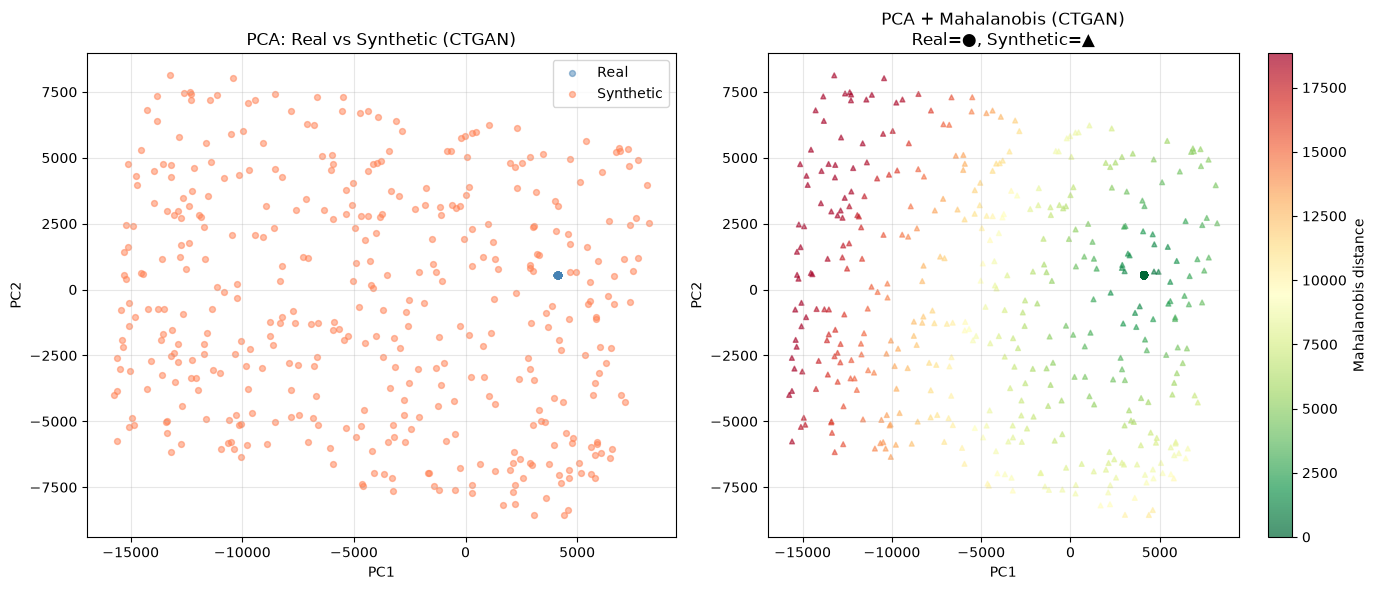

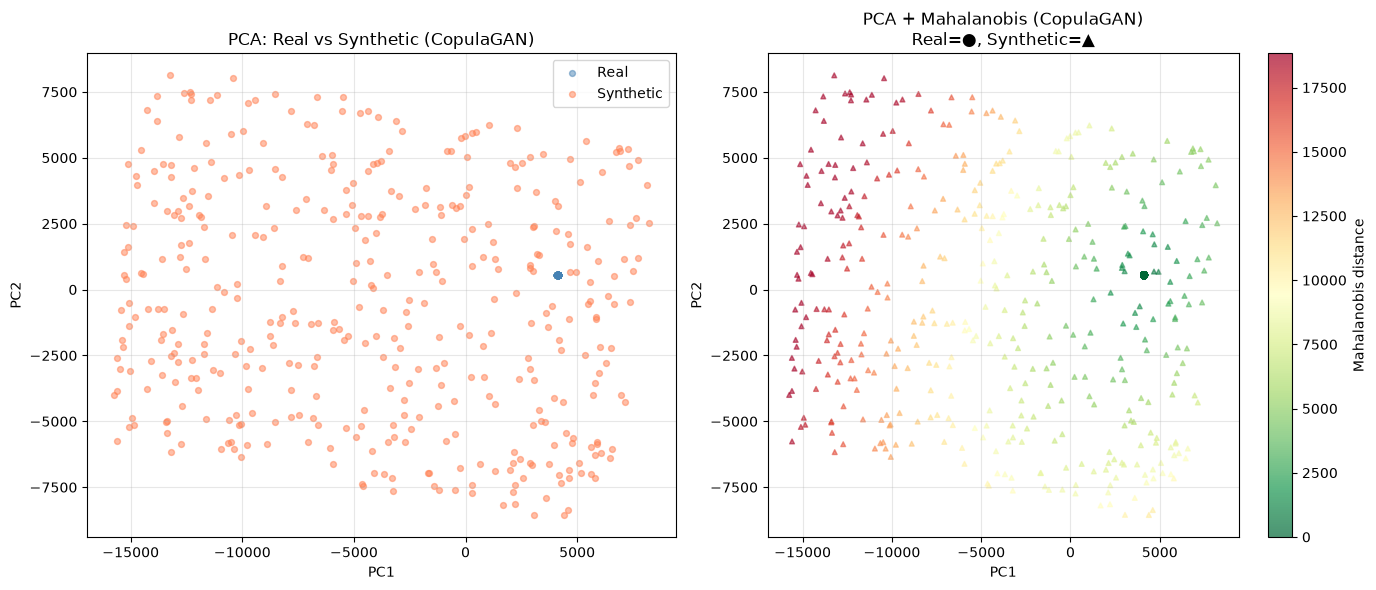

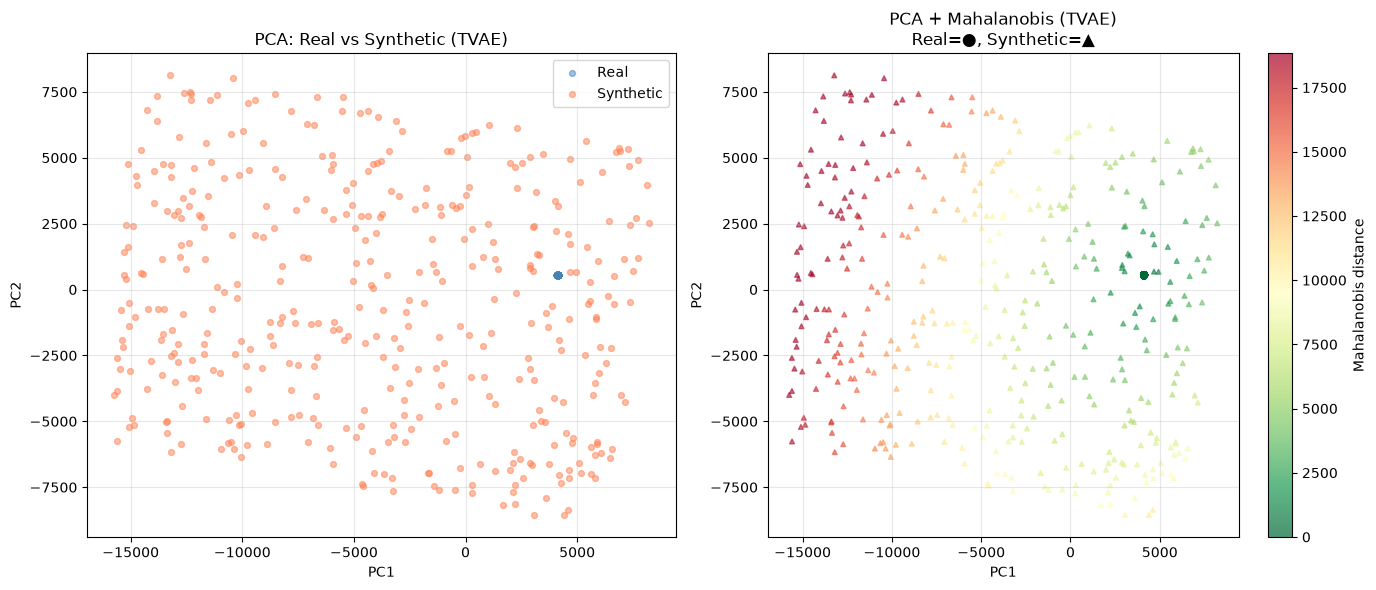

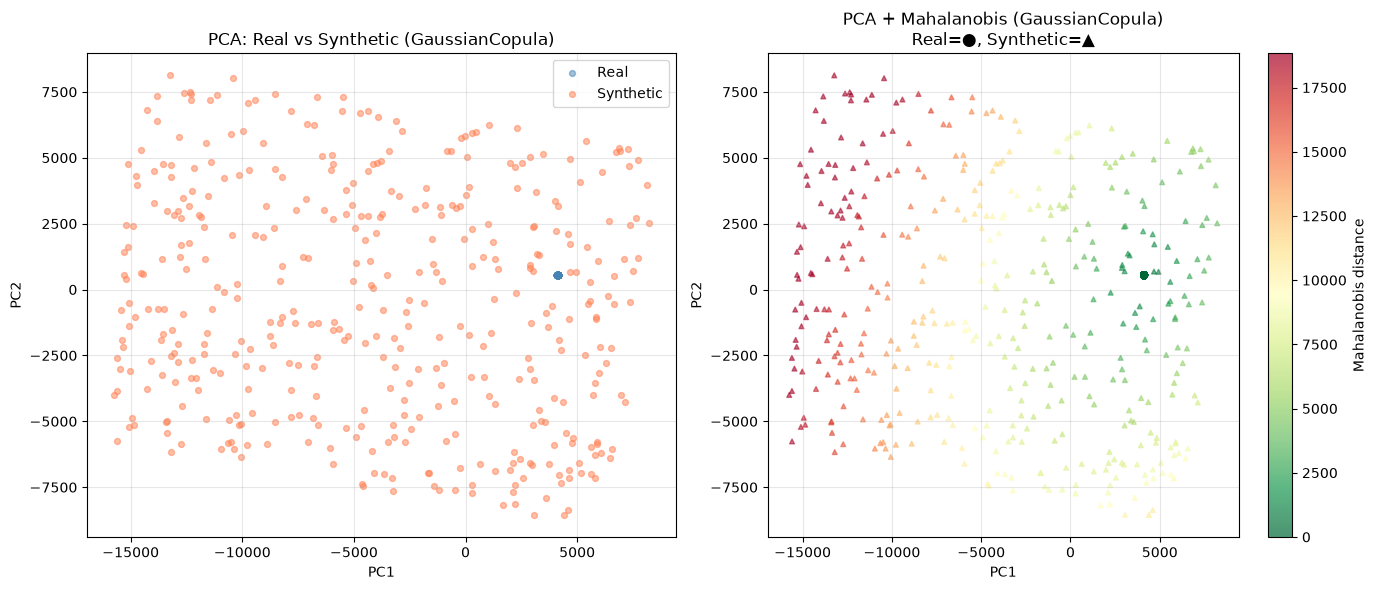

,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
0,CTGAN,1.221502,10686.394424,10685.172921
3,GaussianCopula,1.221507,10686.502796,10685.281289
2,TVAE,1.221503,10686.620082,10685.398579
1,CopulaGAN,1.221505,10686.660855,10685.439350


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "Y house price of unit area"]

X_r = real_df[feature_cols].to_numpy(dtype=np.float64)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synthetic_data:
        print(f"{model_name} not found in synthetic_data, skipping.")
        continue

    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_s = synth_df[feature_cols].to_numpy(dtype=np.float64)
    X_s_s = scaler.transform(X_s)

    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = np.linalg.pinv(cov_z + reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
display(summary_df)


In [44]:
import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "Hungarian_Mahalanobis_Four_Models_RealEstate.xlsx"
):
    model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                continue

            synth_df = synthetic_data[model_name].copy()
            _common = [c for c in real_df.columns if c in synth_df.columns]

            synth_df = synth_df[_common]

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["distances"]
            elif "selected_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["selected_distances"]
            elif "matched_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["matched_distances"]
            else:
                raise KeyError(f"No distance array found for {model_name}")

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Dataset": "RealEstate",
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                for c in num_cols:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            sheet_name = f"RealEstate_{model_name}"[:31]
            matched_df.to_excel(writer, sheet_name=sheet_name, index=False)

            summary_rows.append({
                "Dataset": "RealEstate",
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name="RealEstate_Summary", index=False)

    print(f"Excel file created: {filename}")


# ---- Run ----
real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "Y house price of unit area"]

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_data=synthetic_data,
    hungarian_results=hungarian_results,
    num_cols=num_cols,
    filename="Hungarian_Mahalanobis_Four_Models_RealEstate.xlsx"
)


Excel file created: Hungarian_Mahalanobis_Four_Models_RealEstate.xlsx


# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [45]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample_regression(model, X, y):
    return (y - model.predict(X)) ** 2

def privacy_metrics_mia_regression(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)
    model.fit(X_train_s, y_train)
    loss_train = model_loss_per_sample_regression(model, X_train_s, y_train)
    loss_test = model_loss_per_sample_regression(model, X_test_s, y_test)
    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    return {"AUC": float(roc_auc_score(labels, scores)), "Advantage": float(np.max(tpr - fpr))}

target_col = "Y house price of unit area"
feature_cols = [c for c in data.select_dtypes(include=[np.number]).columns if c != target_col]
real_df = data.copy()
synth_key = next(iter(synthetic_data)) if "synthetic_data" in globals() else next(iter(synthetic_outputs))
synth_src = synthetic_data if "synthetic_data" in globals() else synthetic_outputs
_common = [c for c in real_df.columns if c in synth_src[synth_key].columns]
synth_df = synth_src[synth_key][_common].copy()
model = Ridge(alpha=1.0, random_state=42)
print(privacy_metrics_mia_regression(
    model,
    real_df[feature_cols].to_numpy(dtype=np.float64),
    real_df[target_col].to_numpy(dtype=np.float64),
    synth_df[feature_cols].to_numpy(dtype=np.float64),
    synth_df[target_col].to_numpy(dtype=np.float64),
))


{'AUC': 0.9999941655581227, 'Advantage': 0.9975845410628019}


In [46]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "Y house price of unit area"]
X_train = data[feature_cols].to_numpy(dtype=np.float64)

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
rows = []

for model_name in model_order:
    X_test = synthetic_data[model_name][feature_cols].to_numpy(dtype=np.float64)
    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

comparison_df = pd.DataFrame(rows)[
    ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
].sort_values("AUC", ascending=False).reset_index(drop=True)

print("MIA (Mahalanobis) comparison across 4 synthetic models:")
display(comparison_df)


MIA (Mahalanobis) comparison across 4 synthetic models:


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,CTGAN,1.0,1.0,1.0,2.08473,16797.263963
1,CopulaGAN,1.0,1.0,1.0,2.08473,16798.353439
2,TVAE,1.0,1.0,1.0,2.08473,16798.307804
3,GaussianCopula,1.0,1.0,1.0,2.08473,16798.070859
